# 🌳 Deforestation Prediction using Satellite Data
## Complete End-to-End Predictive Analytics Project

**Dataset:** Brazilian Amazon Deforestation Data (PRODES/INPE) + Satellite Images  
**Author:** Predictive Analytics Project  
**Tech Stack:** Python · scikit-learn · TensorFlow/Keras · PIL · Matplotlib · Seaborn

---

### 📋 Project Structure
| Part | Topic |
|------|-------|
| Part 1 | Text Data Preprocessing & Classification |
| Part 2 | Clustering (K-Means, K-Medoids, Agglomerative, DBSCAN) |
| Part 3 | Deep Learning – Artificial Neural Network (ANN) |
| Part 4 | Image Data – CNN & DNN |
| Part 5 | Transfer Learning & Object Detection |
| Part 6 | GAN – Generative Adversarial Network |
| Part 7 | Prediction & Real-Time Alert System |

---


## 📦 Global Imports & Setup

In [ ]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, glob, time, random
warnings.filterwarnings('ignore')

# ── Sklearn: Preprocessing ────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ── Sklearn: Classification ──────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ── Sklearn: Clustering ──────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# ── Sklearn: Metrics ─────────────────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              silhouette_score)

# ── Image Processing ─────────────────────────────────────────────────────────
from PIL import Image, ImageEnhance, ImageOps

# ── Deep Learning (TensorFlow/Keras) ─────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Conv2D, MaxPooling2D,
                                      Flatten, BatchNormalization, GlobalAveragePooling2D,
                                      Input, LeakyReLU, Reshape, Conv2DTranspose,
                                      UpSampling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans'
})
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("✅ All libraries imported successfully!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   scikit-learn       : imported")
print(f"   NumPy              : {np.__version__}")
print(f"   Pandas             : {pd.__version__}")


✅ All libraries imported successfully!
   TensorFlow version : 2.19.0
   scikit-learn       : imported
   NumPy              : 2.0.2
   Pandas             : 2.2.2


---
# PART 1 — Text Data Processing & Classification

## 📂 Dataset Overview
The **PRODES/INPE Brazilian Amazon Deforestation** dataset contains municipality-level  
satellite measurements from 2000–2021.

| Column | Portuguese | Meaning |
|--------|-----------|---------|
| `ano` | Year | Year of observation |
| `id_municipio` | Municipality ID | Brazilian municipality code |
| `area` | Total area | Total area (km²) |
| `desmatado` | Deforested | Already deforested area |
| `incremento` | Increment | New deforestation this year |
| `floresta` | Forest | Remaining forest area |
| `nuvem` | Cloud | Cloud-obscured area |
| `nao_observado` | Not observed | Unobserved area |
| `nao_floresta` | Non-forest | Non-forest area |
| `hidrografia` | Hydrography | Water bodies area |

**Target variable:** Deforestation risk label derived from deforestation rate:
- 🟢 **Low** — deforestation < 5% of total area  
- 🟡 **Medium** — 5–20%  
- 🔴 **High** — >20%


### 1.1 Load & Inspect Data

In [ ]:
# ── Load CSV ─────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/data.csv')      # adjust path if needed

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()


Dataset shape : 16,720 rows × 10 columns

Column types:
ano                int64
id_municipio       int64
area               int64
desmatado        float64
incremento       float64
floresta         float64
nuvem            float64
nao_observado    float64
nao_floresta     float64
hidrografia      float64
dtype: object

First 5 rows:


,ano,id_municipio,area,desmatado,incremento,floresta,nuvem,nao_observado,nao_floresta,hidrografia
0,2000,1100015,7137,1761.1,NaN,3639.6,0.0,6.1,1708.0,22.2
1,2000,1100023,4481,2661.2,NaN,1730.0,0.0,0.0,89.6,0.2
2,2000,1100031,1322,851.2,NaN,455.2,0.0,0.6,11.3,3.7
3,2000,1100049,3821,2311.3,NaN,1477.7,0.0,0.0,26.2,5.8
4,2000,1100056,2805,731.3,NaN,829.3,0.0,0.0,1244.4,0.0


### 1.2 Statistical Summary

In [ ]:
# ── Descriptive Statistics ───────────────────────────────────────────────────
print("=== Statistical Summary ===")
display(df.describe().T.style.background_gradient(cmap='YlOrRd', axis=0))


=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
ano,16720.000000,2010.500000,6.344479,2000.000000,2005.000000,2010.500000,2016.000000,2021.000000
id_municipio,16720.000000,2292060.607895,1375413.502014,1100015.000000,1502743.750000,1712429.500000,2109213.500000,5108956.000000
area,16720.000000,6668.484211,13857.511878,64.000000,891.750000,2379.500000,6422.000000,159540.000000
desmatado,16720.000000,954.653834,1374.296395,0.000000,120.300000,450.400000,1258.325000,20471.500000
incremento,15960.000000,18.371172,67.631285,0.000000,0.000000,1.200000,9.400000,1808.600000
floresta,16720.000000,3980.076304,11954.043960,0.000000,19.000000,222.650000,2295.425000,152013.600000
nuvem,16720.000000,303.187249,1888.025470,0.000000,0.000000,0.000000,5.100000,68394.900000
nao_observado,16720.000000,95.782614,562.813003,-379.600000,0.000000,0.000000,1.200000,11321.100000
nao_floresta,16720.000000,1264.546304,2401.909519,0.000000,4.600000,195.850000,1436.725000,19780.800000
hidrografia,16720.000000,148.586998,430.376364,0.000000,0.000000,4.350000,65.025000,4499.900000


### 1.3 Missing Value Analysis

Columns with missing values:
            Missing Count  Missing %
incremento            760       4.55


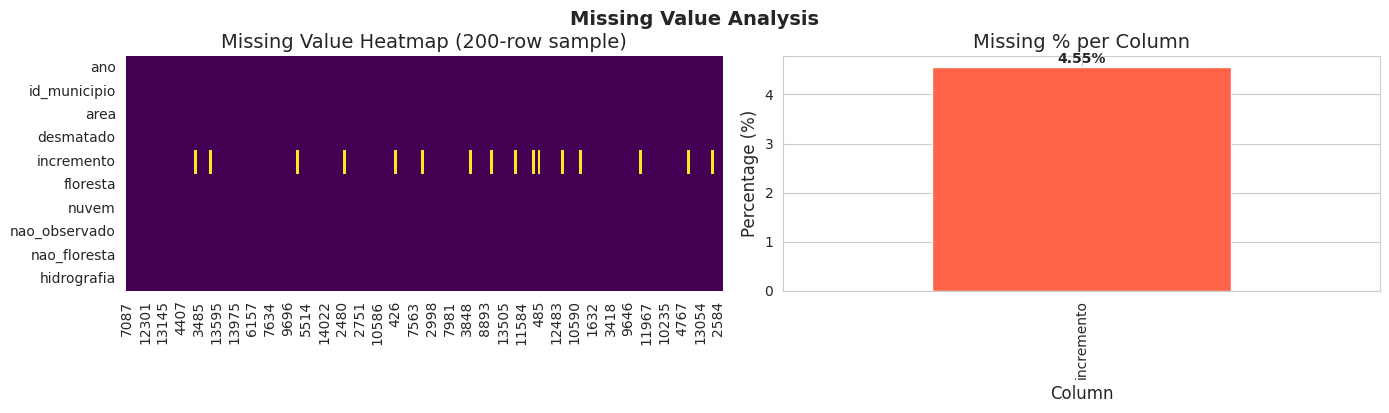

In [ ]:
# ── Missing Values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Columns with missing values:")
print(missing_df)

# ── Visualize ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap of nulls (sample)
sns.heatmap(df.isnull().sample(200, random_state=42).T,
            cbar=False, yticklabels=True, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Value Heatmap (200-row sample)')

# Bar chart
missing_df['Missing %'].plot(kind='bar', color='tomato', ax=axes[1])
axes[1].set_title('Missing % per Column')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Column')
for i, v in enumerate(missing_df['Missing %']):
    axes[1].text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.suptitle('Missing Value Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.show()


### 1.4 Fill Missing Values & Feature Engineering

Filled 'incremento' missing values with median = 1.20

Class distribution:
label
High      9243
Low       5167
Medium    2310
Name: count, dtype: int64


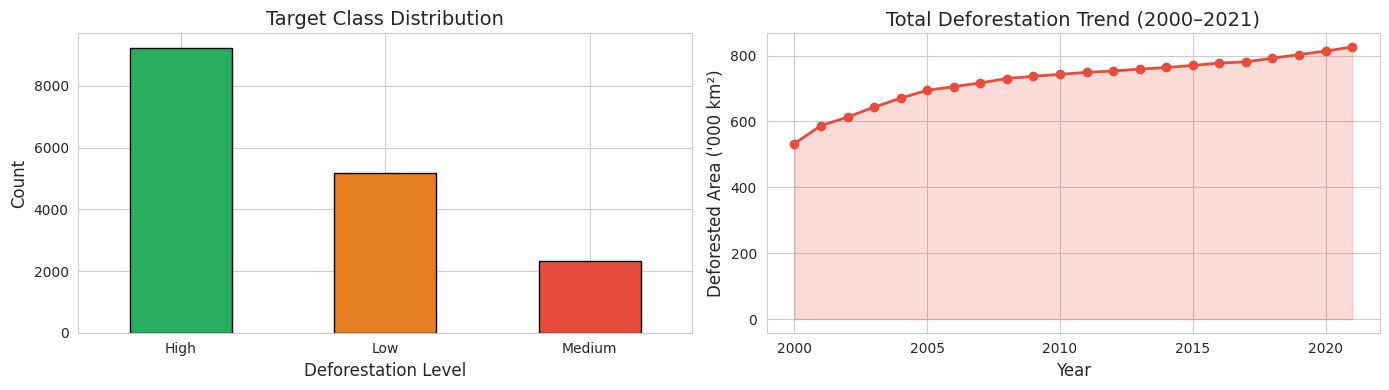

In [ ]:
# ── Impute 'incremento' with its median ──────────────────────────────────────
median_val = df['incremento'].median()
df['incremento'] = df['incremento'].fillna(median_val)
print(f"Filled 'incremento' missing values with median = {median_val:.2f}")

# ── Derived features ─────────────────────────────────────────────────────────
df['deforestation_rate'] = df['desmatado'] / df['area'] * 100     # % deforested
df['forest_cover_pct']   = df['floresta']  / df['area'] * 100     # % forest
df['cloud_pct']          = df['nuvem']     / df['area'] * 100     # % cloud cover

# ── Target label ─────────────────────────────────────────────────────────────
def classify_deforestation(rate):
    if rate < 5:   return 'Low'
    elif rate < 20: return 'Medium'
    else:           return 'High'

df['label'] = df['deforestation_rate'].apply(classify_deforestation)
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print("\nClass distribution:")
print(df['label'].value_counts())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class balance
colors = ['#27ae60', '#e67e22', '#e74c3c']
df['label'].value_counts().plot(kind='bar', color=colors, edgecolor='black', ax=axes[0])
axes[0].set_title('Target Class Distribution')
axes[0].set_xlabel('Deforestation Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Deforestation trend over years
yearly = df.groupby('ano')['desmatado'].sum() / 1000
axes[1].plot(yearly.index, yearly.values, marker='o', color='#e74c3c', linewidth=2)
axes[1].fill_between(yearly.index, yearly.values, alpha=0.2, color='#e74c3c')
axes[1].set_title('Total Deforestation Trend (2000–2021)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel("Deforested Area ('000 km²)")

plt.tight_layout()
plt.show()


### 1.5 Feature Correlation Heatmap

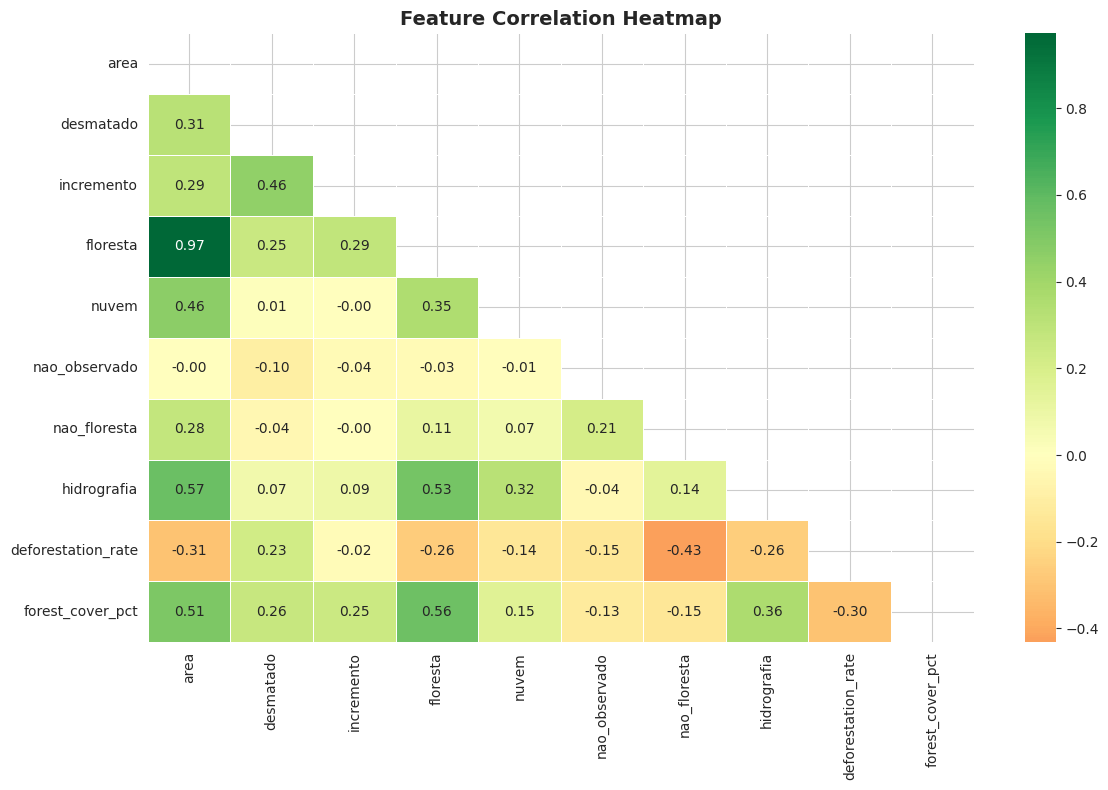

In [ ]:
features = ['area','desmatado','incremento','floresta','nuvem',
            'nao_observado','nao_floresta','hidrografia',
            'deforestation_rate','forest_cover_pct']

plt.figure(figsize=(12, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.6 Train / Test Split & Scaling

In [ ]:
FEATURES = ['area','desmatado','incremento','floresta','nuvem',
            'nao_observado','nao_floresta','hidrografia',
            'deforestation_rate','forest_cover_pct','cloud_pct']

X = df[FEATURES].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Features     : {len(FEATURES)}")
print(f"Classes      : {le.classes_}")


Training set : 13,376 samples
Test set     : 3,344 samples
Features     : 11
Classes      : ['High' 'Low' 'Medium']


### 1.7 Classification Models

In [ ]:
# ── Model definitions ────────────────────────────────────────────────────────
models = {
    'SVM'                : SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE, probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=150, max_depth=12,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                               multi_class='auto', solver='lbfgs'),
}

# ── Training & Evaluation ──────────────────────────────────────────────────────
results = {}
trained_models = {}

print("Training models...")
print("-" * 60)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    elapsed = time.time() - t0

    results[name] = {
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, preds, average='weighted'),
        'F1-Score' : f1_score(y_test, preds, average='weighted'),
        'Time (s)' : round(elapsed, 2)
    }
    trained_models[name] = (model, preds)
    print(f"  ✅ {name:<22} | Acc={results[name]['Accuracy']:.3f} | "
          f"F1={results[name]['F1-Score']:.3f} | {elapsed:.1f}s")

print("-" * 60)


Training models...
------------------------------------------------------------
  ✅ SVM                    | Acc=0.988 | F1=0.988 | 6.6s
  ✅ K-Nearest Neighbors    | Acc=0.982 | F1=0.982 | 0.2s
  ✅ Decision Tree          | Acc=1.000 | F1=1.000 | 0.0s
  ✅ Random Forest          | Acc=1.000 | F1=1.000 | 1.6s
  ✅ Logistic Regression    | Acc=0.994 | F1=0.994 | 0.2s
------------------------------------------------------------


### 1.8 Model Comparison

,Accuracy,Precision,Recall,F1-Score,Time (s)
Decision Tree,1.000,1.000,1.000,1.000,0.02
Random Forest,1.000,1.000,1.000,1.000,1.64
Logistic Regression,0.994,0.994,0.994,0.994,0.22
SVM,0.988,0.988,0.988,0.988,6.61
K-Nearest Neighbors,0.982,0.982,0.982,0.982,0.19


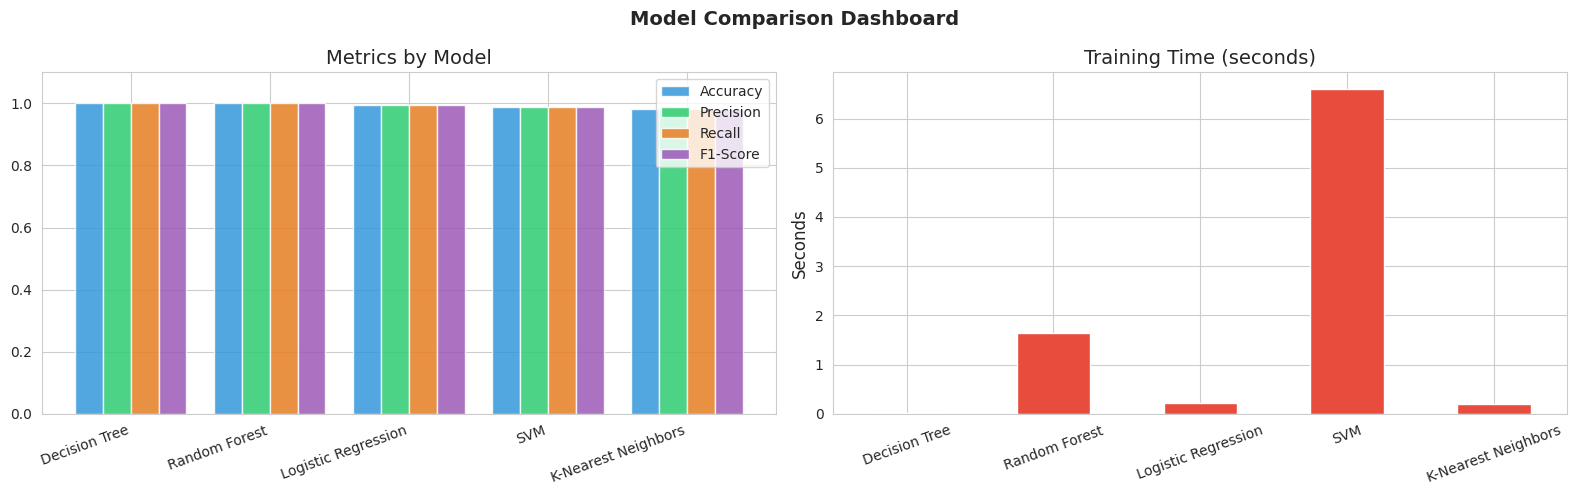


🏆 Best Model: Decision Tree  (F1 = 1.0000)


In [ ]:
results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
display(results_df.style
        .background_gradient(subset=['Accuracy','Precision','Recall','F1-Score'],
                             cmap='YlGn')
        .format({'Accuracy':'{:.3f}','Precision':'{:.3f}',
                 'Recall':'{:.3f}','F1-Score':'{:.3f}','Time (s)':'{:.2f}'})
        .set_caption('🏆 Model Performance Comparison'))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2
palette = ['#3498db','#2ecc71','#e67e22','#9b59b6']

for i, m in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[m], width, label=m, color=palette[i], alpha=0.85)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(results_df.index, rotation=20, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_title('Metrics by Model')

# Training time
results_df['Time (s)'].plot(kind='bar', color='#e74c3c', ax=axes[1])
axes[1].set_title('Training Time (seconds)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Model Comparison Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = results_df['F1-Score'].idxmax()
print(f"\n🏆 Best Model: {best_model_name}  (F1 = {results_df.loc[best_model_name,'F1-Score']:.4f})")


### 1.9 Confusion Matrices

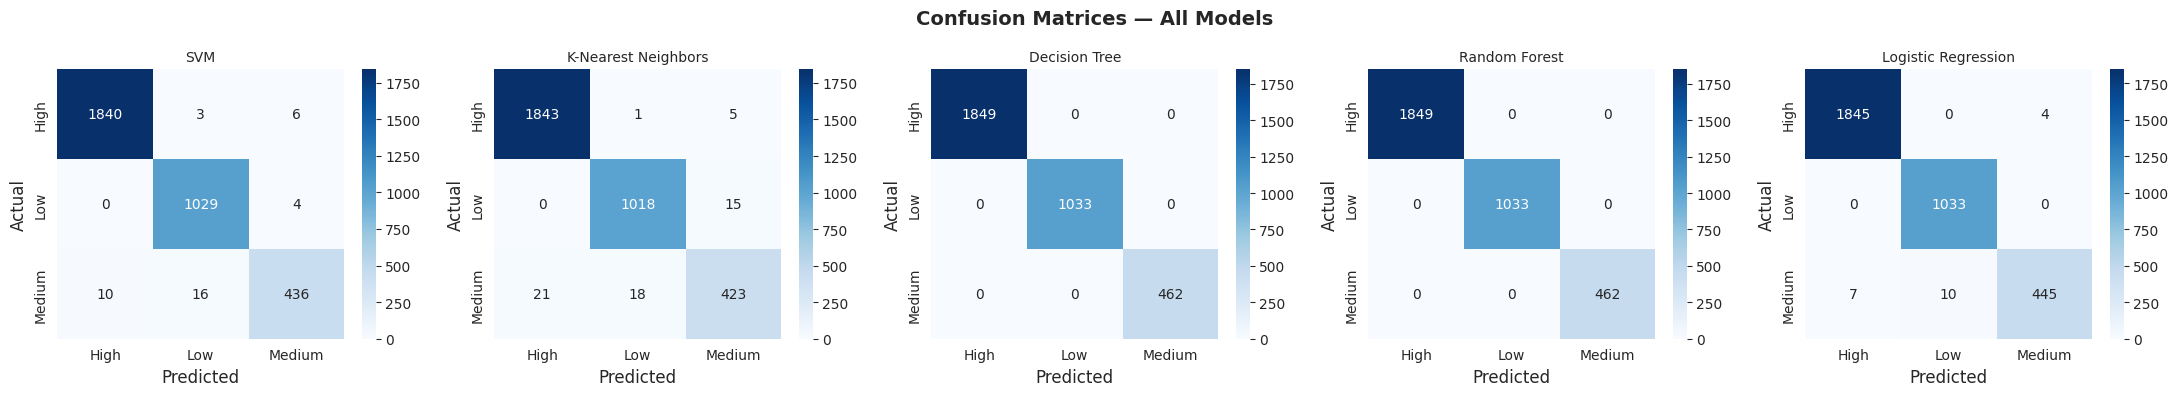

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
class_names = le.classes_

for ax, (name, (model, preds)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.10 Best Model — Detailed Report

=== Decision Tree — Detailed Classification Report ===

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1849
         Low       1.00      1.00      1.00      1033
      Medium       1.00      1.00      1.00       462

    accuracy                           1.00      3344
   macro avg       1.00      1.00      1.00      3344
weighted avg       1.00      1.00      1.00      3344



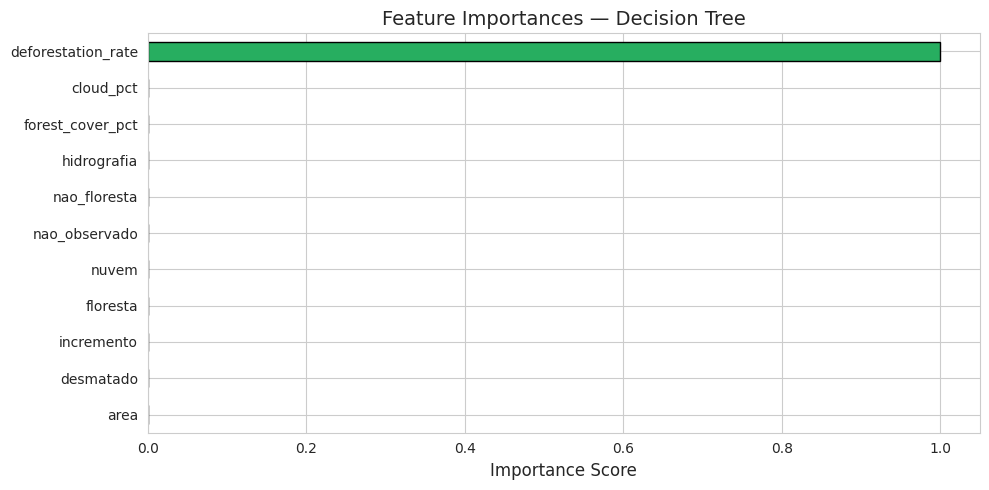

In [ ]:
best_model, best_preds = trained_models[best_model_name]
print(f"=== {best_model_name} — Detailed Classification Report ===\n")
print(classification_report(y_test, best_preds, target_names=class_names))

# Feature importance (if tree-based)
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    plt.figure(figsize=(10, 5))
    fi.plot(kind='barh', color='#27ae60', edgecolor='black')
    plt.title(f'Feature Importances — {best_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()


---
# PART 2 — Clustering

Unsupervised learning to discover natural groupings in the deforestation data  
without using labels.  
We apply **4 algorithms**:
- **K-Means** — centroid-based
- **K-Medoids** — robust centroid (uses actual data points)
- **Agglomerative** — hierarchical linkage
- **DBSCAN** — density-based (finds noise/outliers)


### 2.1 Prepare Data for Clustering

In [ ]:
# Use a stratified 3,000-sample subset for speed (full data also works)
df_sample = df.sample(3000, random_state=RANDOM_STATE).reset_index(drop=True)

CLUSTER_FEATURES = ['deforestation_rate','forest_cover_pct','cloud_pct',
                     'hidrografia','nao_floresta']

Xc = StandardScaler().fit_transform(df_sample[CLUSTER_FEATURES])
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Xc_2d = pca2.fit_transform(Xc)

print(f"Clustering data shape : {Xc.shape}")
print(f"PCA explained variance: {pca2.explained_variance_ratio_.sum()*100:.1f}%")


Clustering data shape : (3000, 5)
PCA explained variance: 60.7%


### 2.2 Elbow Method — Optimal K

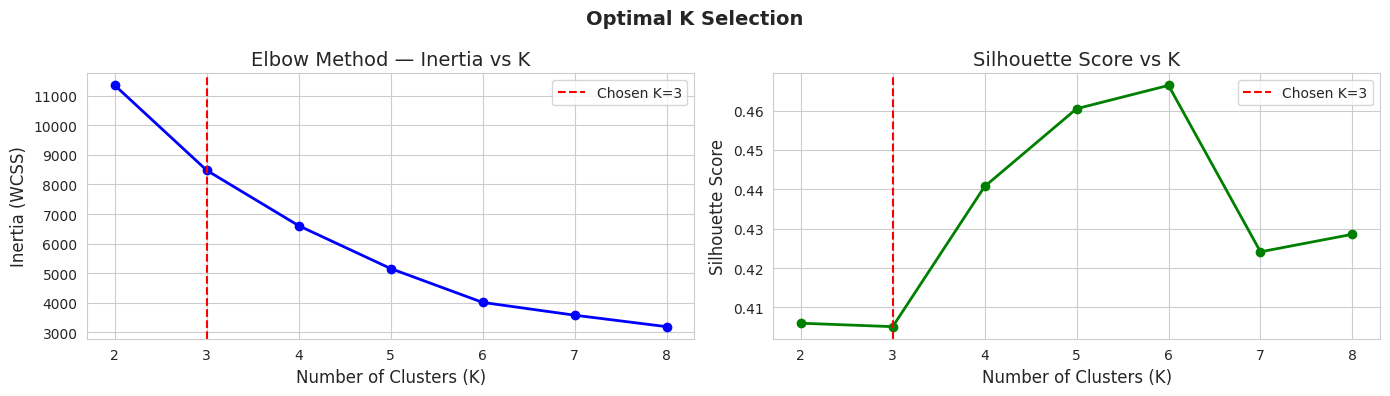

Best K by silhouette: 6


In [ ]:
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km_temp = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km_temp.fit(Xc)
    inertias.append(km_temp.inertia_)
    sil_scores.append(silhouette_score(Xc, km_temp.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(x=3, color='red', linestyle='--', label='Chosen K=3')
axes[0].legend()

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=3, color='red', linestyle='--', label='Chosen K=3')
axes[1].legend()

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best K by silhouette: {K_range[np.argmax(sil_scores)]}")


### 2.3 Apply All Clustering Algorithms

In [ ]:
N_CLUSTERS = 3

# ── 1. K-Means ────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(Xc)

# ── 2. K-Medoids (via custom implementation using sklearn base) ────────────────
# sklearn doesn't ship KMedoids; we implement a simple PAM-inspired version
def simple_kmedoids(X, k, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)
    medoid_idx = rng.choice(len(X), k, replace=False)
    for _ in range(max_iter):
        dists = np.array([np.linalg.norm(X - X[m], axis=1) for m in medoid_idx])
        labels = np.argmin(dists, axis=0)
        new_medoids = []
        for c in range(k):
            cluster_pts = np.where(labels == c)[0]
            if len(cluster_pts) == 0:
                new_medoids.append(medoid_idx[c])
                continue
            intra = np.sum(np.linalg.norm(X[cluster_pts][:,None] - X[cluster_pts][None,:], axis=2), axis=1)
            new_medoids.append(cluster_pts[np.argmin(intra)])
        if np.array_equal(sorted(new_medoids), sorted(medoid_idx)):
            break
        medoid_idx = np.array(new_medoids)
    return labels

kmed_labels = simple_kmedoids(Xc, N_CLUSTERS, random_state=RANDOM_STATE)

# ── 3. Agglomerative ─────────────────────────────────────────────────────────
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
agg_labels = agg.fit_predict(Xc)

# ── 4. DBSCAN ────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=0.6, min_samples=10)
db_labels = dbscan.fit_predict(Xc)

n_noise = np.sum(db_labels == -1)
print(f"DBSCAN clusters found : {len(set(db_labels)) - (1 if -1 in db_labels else 0)}")
print(f"DBSCAN noise points   : {n_noise} ({n_noise/len(Xc)*100:.1f}%)")

# ── Silhouette scores ─────────────────────────────────────────────────────────
def safe_sil(X, labels):
    valid = labels != -1
    if len(set(labels[valid])) < 2:
        return float('nan')
    return silhouette_score(X[valid], labels[valid])

cluster_results = {
    'K-Means'        : km_labels,
    'K-Medoids'      : kmed_labels,
    'Agglomerative'  : agg_labels,
    'DBSCAN'         : db_labels,
}

print("\nSilhouette Scores:")
for name, lbl in cluster_results.items():
    s = safe_sil(Xc, lbl)
    print(f"  {name:<18}: {s:.4f}")


DBSCAN clusters found : 4
DBSCAN noise points   : 296 (9.9%)

Silhouette Scores:
  K-Means           : 0.4051
  K-Medoids         : 0.3045
  Agglomerative     : 0.3216
  DBSCAN            : 0.2740


### 2.4 PCA 2-D Cluster Visualizations

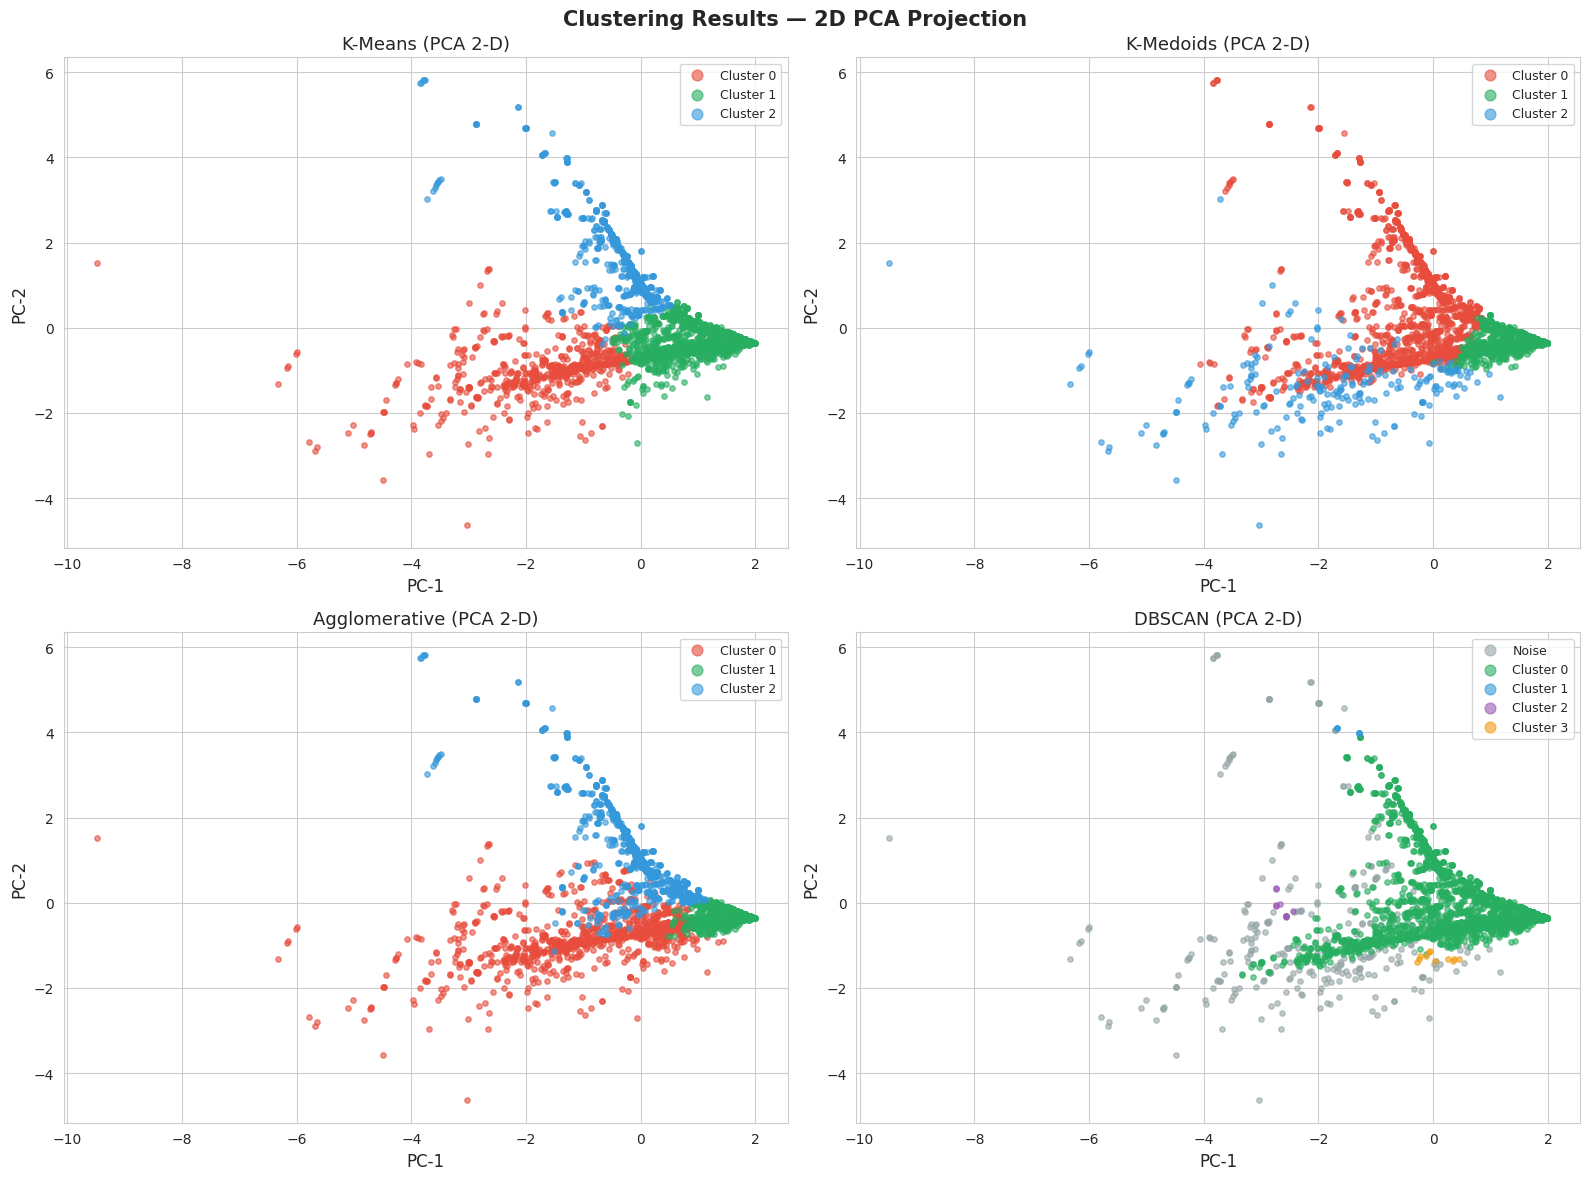

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

palette = ['#e74c3c', '#27ae60', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']

for ax, (name, labels) in zip(axes, cluster_results.items()):
    unique_labels = sorted(set(labels))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        color = '#95a5a6' if lbl == -1 else palette[i % len(palette)]
        label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(Xc_2d[mask, 0], Xc_2d[mask, 1],
                   c=color, s=15, alpha=0.6, label=label_str)
    ax.set_title(f'{name} (PCA 2-D)', fontsize=13)
    ax.set_xlabel('PC-1')
    ax.set_ylabel('PC-2')
    ax.legend(markerscale=2, fontsize=9)

plt.suptitle('Clustering Results — 2D PCA Projection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.5 Cluster Profiles — K-Means

K-Means Cluster Profiles (mean values):


,Deforestation Rate,Forest Cover Pct,Cloud Pct,Hidrografia,Nao Floresta
Cluster 0,10.28,71.71,6.63,519.63,824.56
Cluster 1,66.03,17.51,1.71,27.77,171.41
Cluster 2,5.17,6.83,0.30,47.70,3555.09


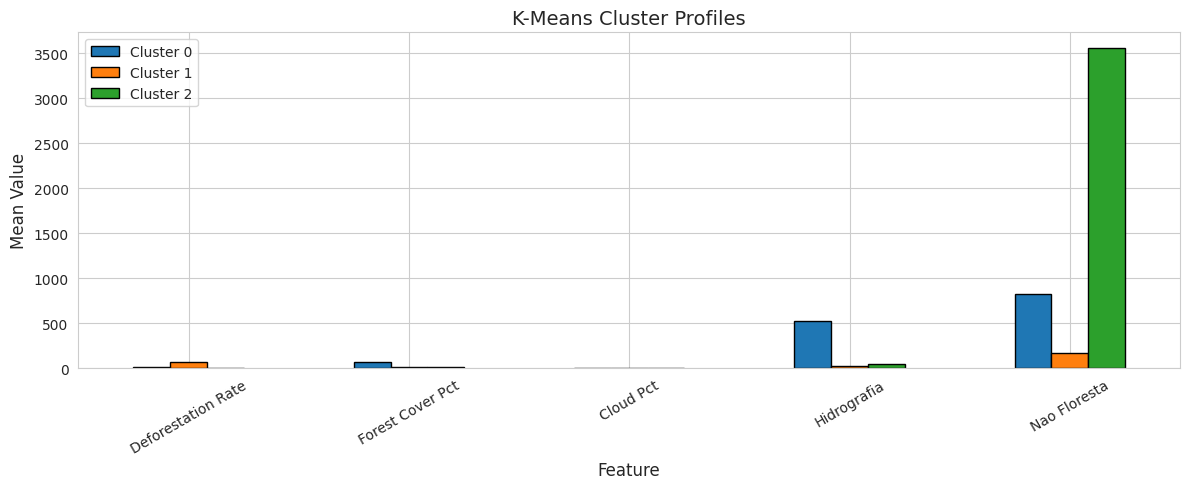

In [ ]:
# Add K-Means cluster labels to sample dataframe
df_sample['cluster'] = km_labels

profile = df_sample.groupby('cluster')[CLUSTER_FEATURES + ['label']].agg(
    {f: 'mean' for f in CLUSTER_FEATURES}
)
profile.columns = [f.replace('_',' ').title() for f in CLUSTER_FEATURES]
profile.index = [f'Cluster {i}' for i in profile.index]

print("K-Means Cluster Profiles (mean values):")
display(profile.style
        .background_gradient(cmap='RdYlGn_r', axis=0)
        .format('{:.2f}'))

# Radar not possible without extra pkg; use grouped bar
profile_t = profile.T
ax = profile_t.plot(kind='bar', figsize=(12, 5), edgecolor='black')
ax.set_title('K-Means Cluster Profiles')
ax.set_xlabel('Feature')
ax.set_ylabel('Mean Value')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


---
# PART 3 — Deep Learning: Artificial Neural Network (ANN)

An ANN learns non-linear decision boundaries through stacked layers of neurons.  
Architecture:
```
Input (11 features) → [Dense 256, ReLU, BN, Dropout 0.3]
                     → [Dense 128, ReLU, BN, Dropout 0.3]
                     → [Dense 64,  ReLU, BN, Dropout 0.2]
                     → Output (3, Softmax)
```


In [ ]:
# ── Prepare data ──────────────────────────────────────────────────────────────
X_ann_train = X_train_s.astype('float32')
X_ann_test  = X_test_s.astype('float32')
y_ann_train = to_categorical(y_train, num_classes=3)
y_ann_test  = to_categorical(y_test,  num_classes=3)

print(f"ANN input shape  : {X_ann_train.shape}")
print(f"ANN output shape : {y_ann_train.shape}")


ANN input shape  : (13376, 11)
ANN output shape : (13376, 3)


In [ ]:
# ── Build ANN ─────────────────────────────────────────────────────────────────
def build_ann(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),

        # ── Hidden Layer 1 ──
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.30),

        # ── Hidden Layer 2 ──
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.30),

        # ── Hidden Layer 3 ──
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.20),

        # ── Output Layer ──
        Dense(num_classes, activation='softmax')
    ], name='ANN_Deforestation')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

ann_model = build_ann(X_ann_train.shape[1], 3)
ann_model.summary()


Model: "ANN_Deforestation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,211 (180.51 KB)

 Trainable params: 45,315 (177.01 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# ── Train ANN ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6)
]

history_ann = ann_model.fit(
    X_ann_train, y_ann_train,
    validation_split=0.15,
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8535 - loss: 0.3735 - val_accuracy: 0.8286 - val_loss: 0.4052 - learning_rate: 0.0010
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9354 - loss: 0.1666 - val_accuracy: 0.7658 - val_loss: 0.4201 - learning_rate: 0.0010
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9512 - loss: 0.1219 - val_accuracy: 0.8321 - val_loss: 0.2858 - learning_rate: 0.0010
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9571 - loss: 0.1100 - val_accuracy: 0.8874 - val_loss: 0.2044 - learning_rate: 0.0010
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9621 - loss: 0.0956 - val_accuracy: 0.9686 - val_loss: 0.0844 - learning_rate: 0.0010
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9668 - loss: 0.0817 - val_accuracy: 0.9796 - val_loss: 0.0529 - learning_rate: 0.0010
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9703 - loss: 0.0766 - val

In [ ]:
# ── Evaluate ANN ─────────────────────────────────────────────────────────────
ann_preds_prob = ann_model.predict(X_ann_test)
ann_preds      = np.argmax(ann_preds_prob, axis=1)

ann_acc = accuracy_score(y_test, ann_preds)
ann_f1  = f1_score(y_test, ann_preds, average='weighted')
print(f"ANN Test Accuracy : {ann_acc:.4f}")
print(f"ANN Test F1-Score : {ann_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, ann_preds, target_names=le.classes_))


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ANN Test Accuracy : 0.9961
ANN Test F1-Score : 0.9961

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1849
         Low       1.00      1.00      1.00      1033
      Medium       0.99      0.98      0.99       462

    accuracy                           1.00      3344
   macro avg       0.99      0.99      0.99      3344
weighted avg       1.00      1.00      1.00      3344



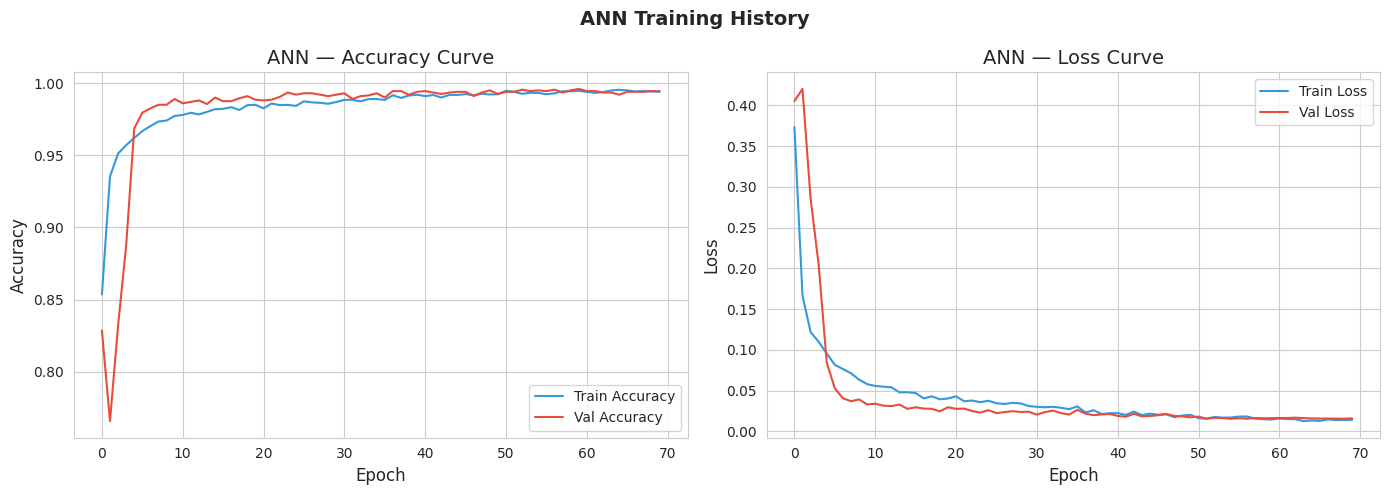

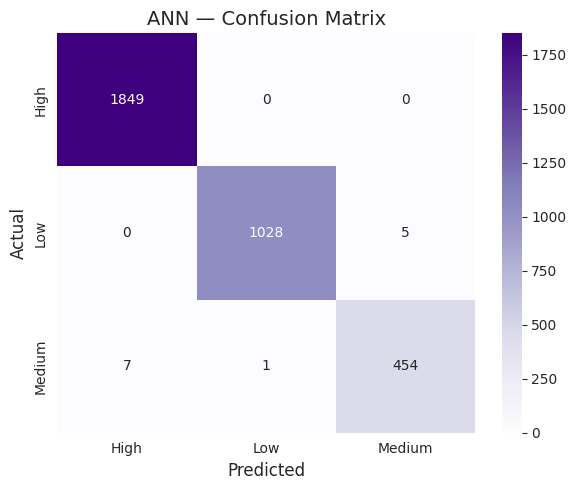

In [ ]:
# ── Visualize Training Curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_ann.history['accuracy'],     label='Train Accuracy', color='#3498db')
axes[0].plot(history_ann.history['val_accuracy'], label='Val Accuracy',   color='#e74c3c')
axes[0].set_title('ANN — Accuracy Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_ann.history['loss'],     label='Train Loss', color='#3498db')
axes[1].plot(history_ann.history['val_loss'], label='Val Loss',   color='#e74c3c')
axes[1].set_title('ANN — Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('ANN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, ann_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('ANN — Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


---
# PART 4 — Image Data: CNN & DNN

We use the uploaded satellite images from the `/deforestation/` folder.  
Since labels aren't explicitly provided per image, we split the images into:
- **Forest** — high-NDVI green images (bright green dominant)
- **Deforested** — low-vegetation, brown/grey dominant

We apply a simple heuristic to auto-label based on green-channel dominance,  
then train CNN and DNN classifiers on 64×64 px patches.

> 💡 **Tip:** For production use, replace auto-labels with a manually annotated CSV.


### Upload and Extract Image Data

In [ ]:
from google.colab import files
import zipfile
import io

print("Please upload the zip file containing your satellite images.")
uploaded = files.upload()

for fn in uploaded.keys():
    zip_ref = zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r')
    # Extract to a new directory to keep things organized
    EXTRACT_PATH = '/content/deforestation_images'
    zip_ref.extractall(EXTRACT_PATH)
    zip_ref.close()
    print(f'Successfully extracted "{fn}" to "{EXTRACT_PATH}"')

IMAGE_DIR = EXTRACT_PATH
print(f'IMAGE_DIR has been set to: {IMAGE_DIR}')

Please upload the zip file containing your satellite images.


Saving archive (11) (1).zip to archive (11) (1).zip
Successfully extracted "archive (11) (1).zip" to "/content/deforestation_images"
IMAGE_DIR has been set to: /content/deforestation_images


In [ ]:
# ── Load & Auto-label Images ──────────────────────────────────────────────────
IMAGE_DIR  = '/content/deforestation_images/deforestation'
IMG_SIZE   = (64, 64)
CLASS_NAMES = ['Deforested', 'Forest']

def load_and_label_images(img_dir, img_size):
    images, labels, paths = [], [], []
    for p in sorted(glob.glob(os.path.join(img_dir, '*.jpeg')) +
                    glob.glob(os.path.join(img_dir, '*.jpg'))  +
                    glob.glob(os.path.join(img_dir, '*.png'))):
        try:
            img = Image.open(p).convert('RGB').resize(img_size)
            arr = np.array(img, dtype=np.float32) / 255.0
            # Heuristic: green dominance → Forest
            g_mean = arr[:,:,1].mean()
            r_mean = arr[:,:,0].mean()
            label = 1 if (g_mean > r_mean and g_mean > 0.35) else 0
            images.append(arr)
            labels.append(label)
            paths.append(os.path.basename(p))
        except Exception as e:
            print(f"  Skipping {p}: {e}")
    return np.array(images), np.array(labels), paths

X_img, y_img, img_paths = load_and_label_images(IMAGE_DIR, IMG_SIZE)

print(f"Images loaded : {len(X_img)}")
print(f"Forest (1)    : {y_img.sum()}")
print(f"Deforested (0): {(y_img==0).sum()}")
print(f"Image shape   : {X_img[0].shape}")

Images loaded : 77
Forest (1)    : 29
Deforested (0): 48
Image shape   : (64, 64, 3)


Dataset after augmentation: 200 images


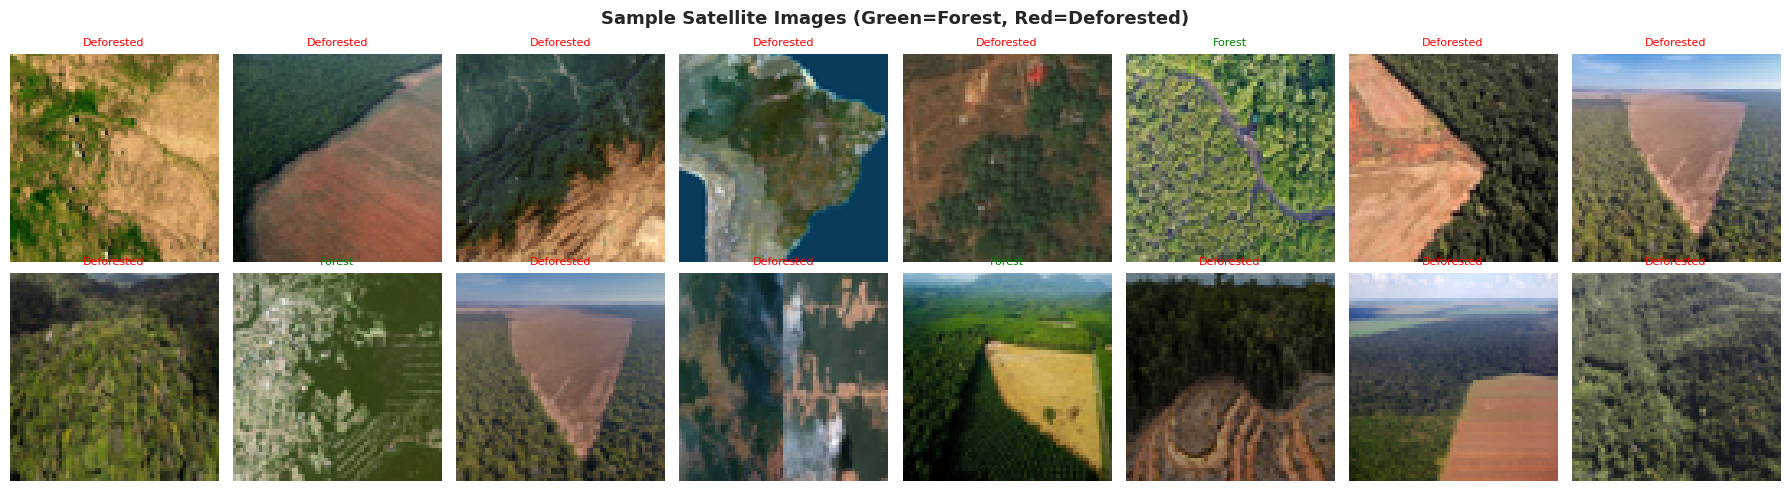

In [ ]:
# ── Data Augmentation ────────────────────────────────────────────────────────
def augment_image(img):
    """Apply random flip, brightness, and rotation augmentations."""
    pil_img = Image.fromarray((img * 255).astype(np.uint8))
    if random.random() > 0.5:
        pil_img = ImageOps.mirror(pil_img)
    if random.random() > 0.5:
        pil_img = ImageOps.flip(pil_img)
    factor = random.uniform(0.8, 1.2)
    pil_img = ImageEnhance.Brightness(pil_img).enhance(factor)
    return np.array(pil_img, dtype=np.float32) / 255.0

# Augment to reach ~200 samples minimum
AUG_TARGET = 200
if len(X_img) < AUG_TARGET:
    extra_imgs, extra_labels = [], []
    while len(X_img) + len(extra_imgs) < AUG_TARGET:
        idx = random.randint(0, len(X_img) - 1)
        extra_imgs.append(augment_image(X_img[idx]))
        extra_labels.append(y_img[idx])
    X_img = np.vstack([X_img, np.array(extra_imgs)])
    y_img = np.hstack([y_img, np.array(extra_labels)])

print(f"Dataset after augmentation: {len(X_img)} images")

# ── Sample grid ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.ravel()):
    idx = random.randint(0, len(X_img) - 1)
    ax.imshow(X_img[idx])
    ax.set_title(CLASS_NAMES[y_img[idx]], fontsize=8,
                 color='green' if y_img[idx] == 1 else 'red')
    ax.axis('off')
plt.suptitle('Sample Satellite Images (Green=Forest, Red=Deforested)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Train/Test Split ─────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_img, y_img, test_size=0.20, random_state=RANDOM_STATE, stratify=y_img)

y_tr_cat = to_categorical(y_tr, 2)
y_te_cat = to_categorical(y_te, 2)

print(f"Train : {X_tr.shape},  Test : {X_te.shape}")


Train : (160, 64, 64, 3),  Test : (40, 64, 64, 3)


### 4.1 Convolutional Neural Network (CNN)

In [ ]:
def build_cnn(input_shape=(64, 64, 3), num_classes=2):
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Classifier
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.50),
        Dense(num_classes, activation='softmax')
    ], name='CNN_Deforestation')

    model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()


Model: "CNN_Deforestation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,239,266 (8.54 MB)

 Trainable params: 2,238,306 (8.54 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
cnn_callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6)
]

history_cnn = cnn_model.fit(
    X_tr, y_tr_cat,
    validation_split=0.15,
    epochs=60,
    batch_size=16,
    callbacks=cnn_callbacks,
    verbose=1
)


Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 438ms/step - accuracy: 0.6765 - loss: 0.8268 - val_accuracy: 0.4583 - val_loss: 0.7008 - learning_rate: 0.0010
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 535ms/step - accuracy: 0.8088 - loss: 0.4428 - val_accuracy: 0.5417 - val_loss: 0.7971 - learning_rate: 0.0010
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 386ms/step - accuracy: 0.9044 - loss: 0.2929 - val_accuracy: 0.5417 - val_loss: 1.2225 - learning_rate: 0.0010
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 379ms/step - accuracy: 0.9044 - loss: 0.2658 - val_accuracy: 0.5417 - val_loss: 1.4317 - learning_rate: 0.0010
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 423ms/step - accuracy: 0.9265 - loss: 0.2213 - val_accuracy: 0.5417 - val_loss: 1.8212 - learning_rate: 0.0010
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 470ms/step - accuracy: 0.9118 - loss: 0.1915 - val_accuracy: 0.5417 - val_loss: 2.2974 - learning_rate: 0.0010
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 377ms/step - accuracy: 0.9338 - loss: 0.1655 - val_accuracy: 

### 4.2 Deep Neural Network on Images (DNN)

In [ ]:
def build_dnn_for_images(input_dim, num_classes=2):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu'),
        BatchNormalization(), Dropout(0.4),
        Dense(256, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(), Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ], name='DNN_Image')
    model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Flatten images for DNN
flat_dim = 64 * 64 * 3
dnn_img = build_dnn_for_images(flat_dim)
dnn_img.summary()

history_dnn_img = dnn_img.fit(
    X_tr.reshape(-1, flat_dim), y_tr_cat,
    validation_split=0.15,
    epochs=60,
    batch_size=16,
    callbacks=cnn_callbacks,
    verbose=1
)


Model: "DNN_Image"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,460,034 (24.64 MB)

 Trainable params: 6,458,242 (24.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.5956 - loss: 1.0735 - val_accuracy: 0.5417 - val_loss: 5.9403 - learning_rate: 0.0010
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7500 - loss: 0.6511 - val_accuracy: 0.5417 - val_loss: 3.6431 - learning_rate: 0.0010
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7426 - loss: 0.5274 - val_accuracy: 0.5417 - val_loss: 2.2667 - learning_rate: 0.0010
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7794 - loss: 0.4680 - val_accuracy: 0.5417 - val_loss: 2.0706 - learning_rate: 0.0010
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8676 - loss: 0.3233 - val_accuracy: 0.5417 - val_loss: 2.7659 - learning_rate: 0.0010
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.8676 - loss: 0.2814 - val_accuracy: 0.5417 - val_loss: 2.1655 - learning_rate: 0.0010
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9044 - loss: 0.2485 - val_accuracy: 0.5417

In [ ]:
# ── Evaluate both models ──────────────────────────────────────────────────────
def evaluate_image_model(model, X_te, y_te_cat, y_te, name, flatten=False):
    X_input = X_te.reshape(len(X_te), -1) if flatten else X_te
    loss, acc = model.evaluate(X_input, y_te_cat, verbose=0)
    preds = np.argmax(model.predict(X_input, verbose=0), axis=1)
    print(f"\n=== {name} ===")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Loss     : {loss:.4f}")
    print(classification_report(y_te, preds, target_names=CLASS_NAMES))
    return preds

cnn_preds = evaluate_image_model(cnn_model, X_te, y_te_cat, y_te, 'CNN')
dnn_preds = evaluate_image_model(dnn_img,   X_te, y_te_cat, y_te, 'DNN', flatten=True)



=== CNN ===
  Accuracy : 0.3750
  Loss     : 0.6953
              precision    recall  f1-score   support

  Deforested       0.33      0.04      0.07        24
      Forest       0.38      0.88      0.53        16

    accuracy                           0.38        40
   macro avg       0.36      0.46      0.30        40
weighted avg       0.35      0.38      0.26        40




=== DNN ===
  Accuracy : 0.9000
  Loss     : 0.2999
              precision    recall  f1-score   support

  Deforested       0.92      0.92      0.92        24
      Forest       0.88      0.88      0.88        16

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



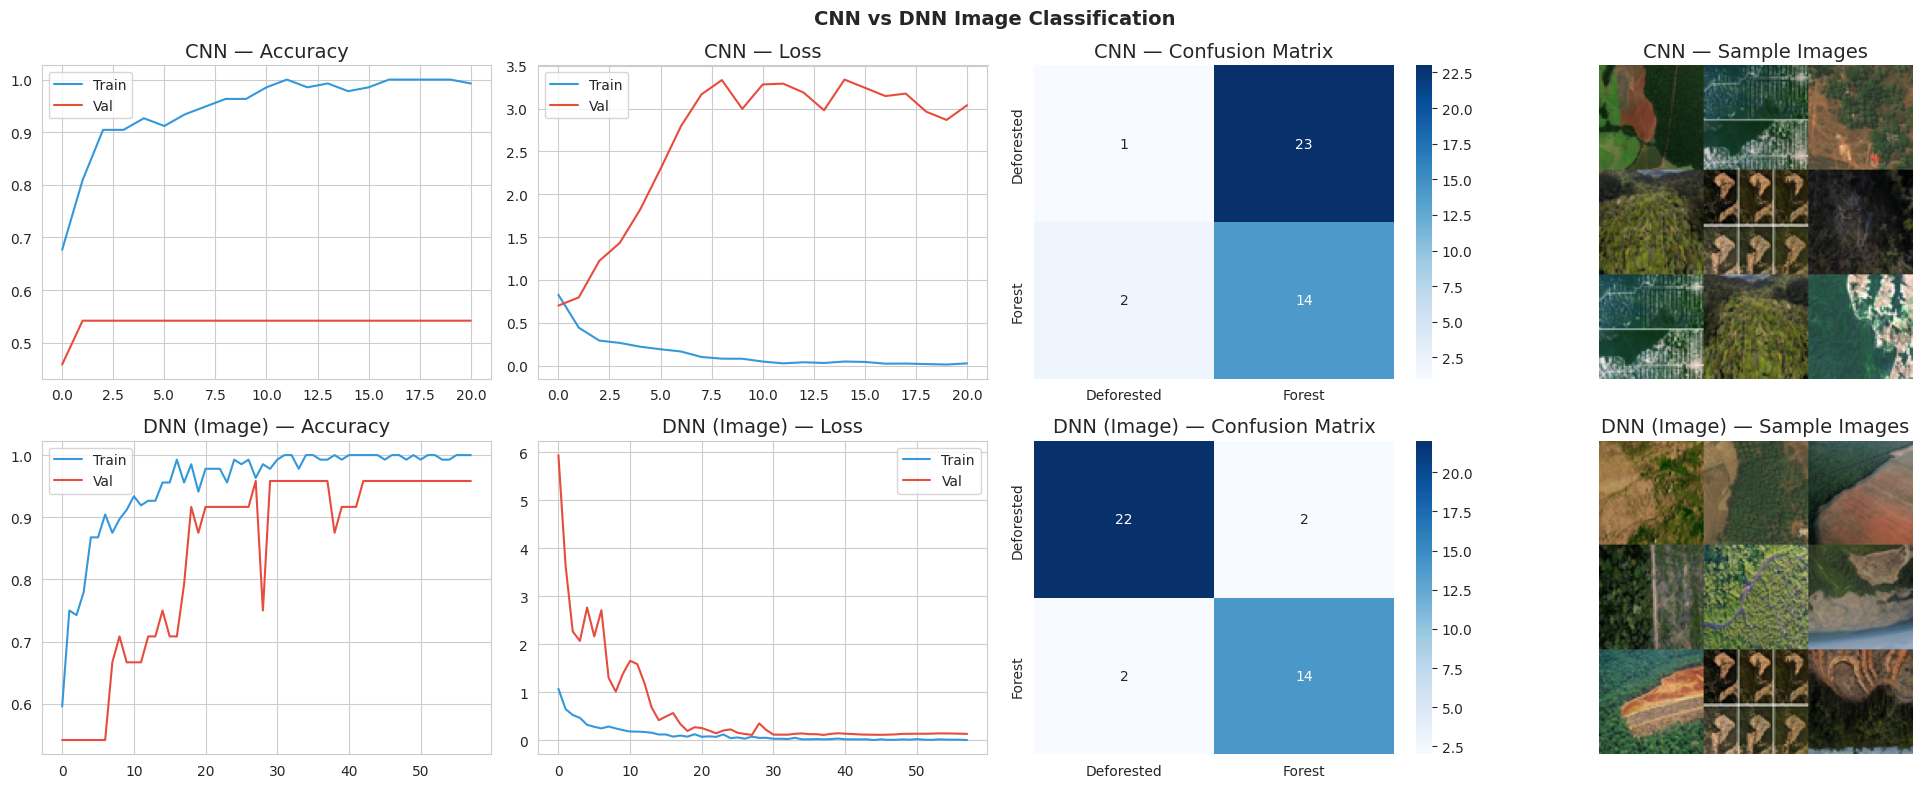

In [ ]:
# ── Plot training curves + confusion matrices ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for row, (hist, name, preds) in enumerate([
        (history_cnn, 'CNN', cnn_preds),
        (history_dnn_img, 'DNN (Image)', dnn_preds)]):
    # Accuracy
    axes[row,0].plot(hist.history['accuracy'],     label='Train', color='#3498db')
    axes[row,0].plot(hist.history['val_accuracy'], label='Val',   color='#e74c3c')
    axes[row,0].set_title(f'{name} — Accuracy')
    axes[row,0].legend()
    # Loss
    axes[row,1].plot(hist.history['loss'],     label='Train', color='#3498db')
    axes[row,1].plot(hist.history['val_loss'], label='Val',   color='#e74c3c')
    axes[row,1].set_title(f'{name} — Loss')
    axes[row,1].legend()
    # Confusion Matrix
    cm = confusion_matrix(y_te, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[row,2])
    axes[row,2].set_title(f'{name} — Confusion Matrix')
    # Sample Predictions
    axes[row,3].axis('off')
    sample_idx = random.sample(range(len(X_te)), 9)
    grid = np.zeros((3*64, 3*64, 3))
    for idx_i, si in enumerate(sample_idx):
        r, c = divmod(idx_i, 3)
        grid[r*64:(r+1)*64, c*64:(c+1)*64] = X_te[si]
    axes[row,3].imshow(grid)
    axes[row,3].set_title(f'{name} — Sample Images')

plt.suptitle('CNN vs DNN Image Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


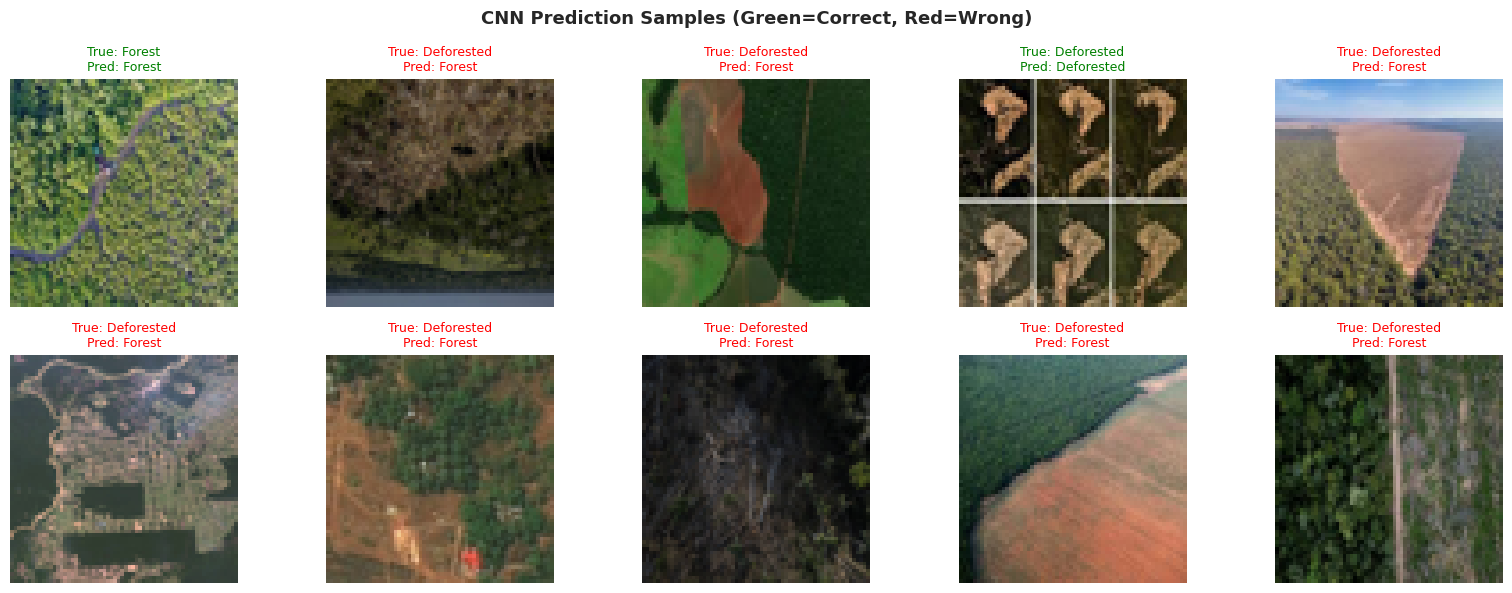

In [ ]:
# ── Visualize CNN Predictions on test samples ──────────────────────────────────
n_show = 10
indices = random.sample(range(len(X_te)), n_show)
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X_te[idx])
    true_lbl = CLASS_NAMES[y_te[idx]]
    pred_lbl = CLASS_NAMES[cnn_preds[idx]]
    color = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('CNN Prediction Samples (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# PART 5 — Transfer Learning & Object Detection

**Why Transfer Learning?**  
Training deep CNNs from scratch requires thousands of images.  
Transfer learning reuses weights learned from ImageNet (1.4M images),  
allowing high accuracy even on small datasets like ours.

**Model chosen: MobileNetV2**  
- Lightweight and fast (suitable for satellite data processing)
- Good accuracy on visual classification tasks
- ImageNet weights → fine-tuned for Forest/Deforested classification


In [ ]:
# ── Build MobileNetV2 Transfer Learning Model ─────────────────────────────────
def build_mobilenet(input_shape=(64, 64, 3), num_classes=2):
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    # Freeze base initially
    base.trainable = False

    inputs = Input(shape=input_shape)
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='MobileNetV2_Transfer')
    model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model, base

tl_model, base_model = build_mobilenet()
tl_model.summary()

print(f"\nTotal params     : {tl_model.count_params():,}")
print(f"Trainable params : {sum(p.numpy().size for p in tl_model.trainable_variables):,}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total params     : 2,422,210
Trainable params : 164,226


In [ ]:
# ── Phase 1: Train head only ──────────────────────────────────────────────────
history_tl1 = tl_model.fit(
    X_tr, y_tr_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=16,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

# ── Phase 2: Fine-tune top 30 layers ─────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(optimizer=Adam(1e-5),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_tl2 = tl_model.fit(
    X_tr, y_tr_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=16,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - accuracy: 0.6250 - loss: 0.8474 - val_accuracy: 0.5417 - val_loss: 0.7465
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8603 - loss: 0.3316 - val_accuracy: 0.7917 - val_loss: 0.5001
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9191 - loss: 0.2444 - val_accuracy: 0.8333 - val_loss: 0.4142
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9559 - loss: 0.1515 - val_accuracy: 0.8750 - val_loss: 0.4061
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 1.0000 - loss: 0.0728 - val_accuracy: 0.8750 - val_loss: 0.3857
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9926 - loss: 0.0789 - val_accuracy: 0.8750 - val_loss: 0.3953
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9926 - loss: 0.0664 - val_accuracy: 0.8750 - val_loss: 0.3691
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 1.0000 - loss: 0.0411 - val_accuracy: 0.8750 - val_loss: 0.3471

MobileNetV2 Test Accuracy : 0.8500
MobileNetV2 Test Loss     : 0.3951

Classification Report:
              precision    recall  f1-score   support

  Deforested       0.85      0.92      0.88        24
      Forest       0.86      0.75      0.80        16

    accuracy                           0.85        40
   macro avg       0.85      0.83      0.84        40
weighted avg       0.85      0.85      0.85        40



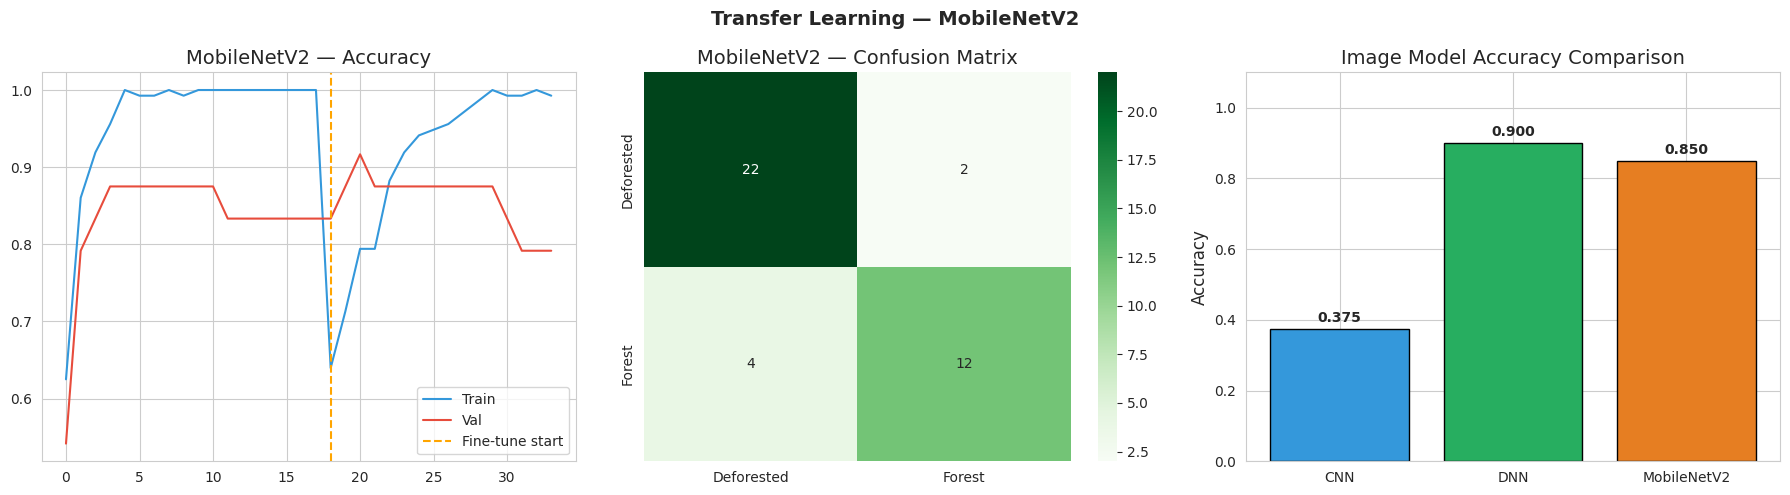

In [ ]:
# ── Evaluate Transfer Learning ────────────────────────────────────────────────
tl_loss, tl_acc = tl_model.evaluate(X_te, y_te_cat, verbose=0)
tl_preds = np.argmax(tl_model.predict(X_te, verbose=0), axis=1)

print(f"MobileNetV2 Test Accuracy : {tl_acc:.4f}")
print(f"MobileNetV2 Test Loss     : {tl_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_te, tl_preds, target_names=CLASS_NAMES))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Combined accuracy history
acc1 = history_tl1.history['accuracy'] + history_tl2.history['accuracy']
val1 = history_tl1.history['val_accuracy'] + history_tl2.history['val_accuracy']
axes[0].plot(acc1, label='Train', color='#3498db')
axes[0].plot(val1, label='Val',   color='#e74c3c')
axes[0].axvline(x=len(history_tl1.history['accuracy']), color='orange',
                linestyle='--', label='Fine-tune start')
axes[0].set_title('MobileNetV2 — Accuracy')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_te, tl_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('MobileNetV2 — Confusion Matrix')

# Model comparison
model_accs = {
    'CNN'        : accuracy_score(y_te, cnn_preds),
    'DNN'        : accuracy_score(y_te, dnn_preds),
    'MobileNetV2': tl_acc
}
axes[2].bar(model_accs.keys(), model_accs.values(),
            color=['#3498db','#27ae60','#e67e22'], edgecolor='black')
axes[2].set_title('Image Model Accuracy Comparison')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1.1)
for i, (k, v) in enumerate(model_accs.items()):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Transfer Learning — MobileNetV2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.2 Bounding Box Object Detection (Sliding Window)

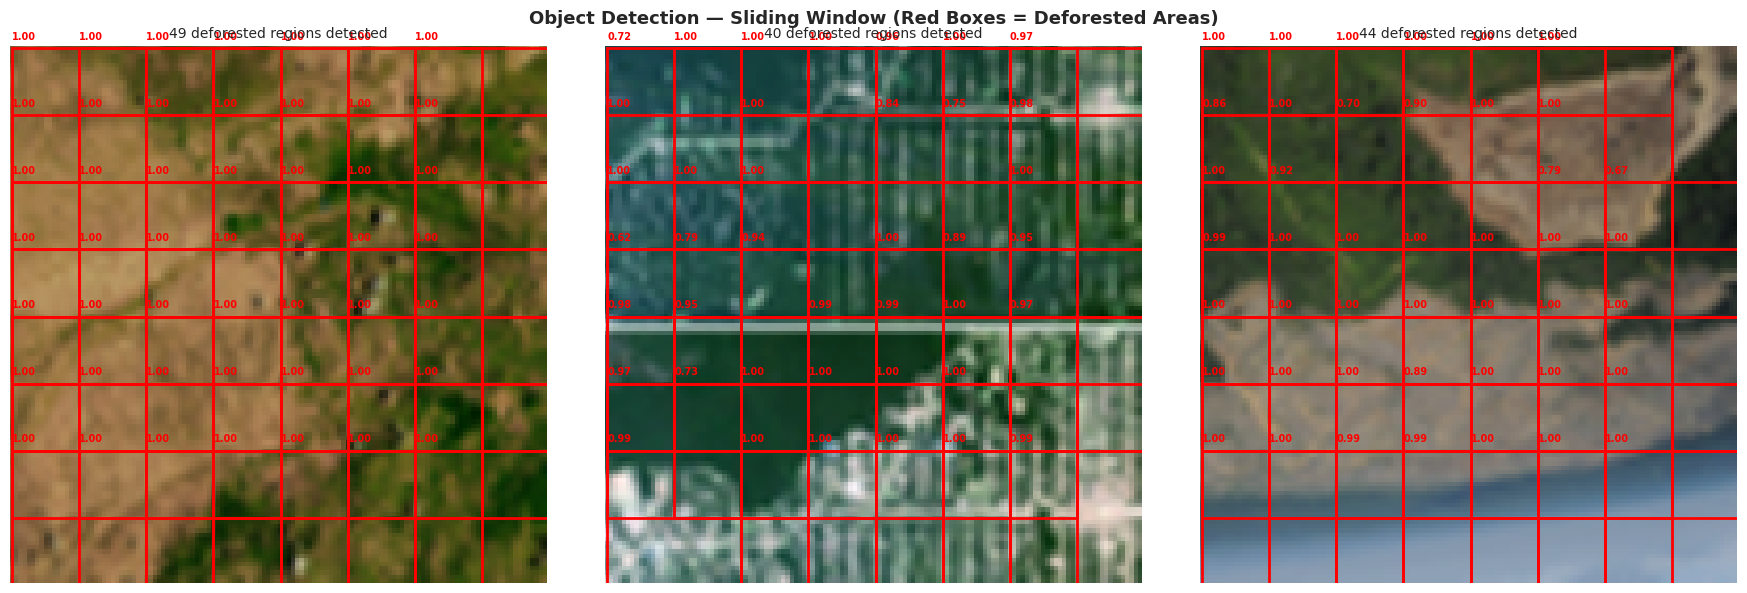

In [ ]:
# ── Sliding-window object detection ──────────────────────────────────────────
# We simulate detection by sliding a window across a test image and
# classifying each patch. Boxes with high "Deforested" probability
# are highlighted as detections.

def sliding_window_detection(model, img_array, window_size=32, stride=16,
                              threshold=0.60):
    """
    Slide a window over img_array (H, W, 3), classify each patch,
    return list of (x, y, w, h, prob_deforested) for boxes above threshold.
    """
    H, W = img_array.shape[:2]
    boxes = []
    patches, coords = [], []
    for y in range(0, H - window_size + 1, stride):
        for x in range(0, W - window_size + 1, stride):
            patch = img_array[y:y+window_size, x:x+window_size]
            resized = np.array(Image.fromarray(
                (patch * 255).astype(np.uint8)).resize((64, 64))) / 255.0
            patches.append(resized)
            coords.append((x, y))

    if patches:
        preds = model.predict(np.array(patches), verbose=0)
        for (x, y), prob in zip(coords, preds):
            if prob[0] > threshold:          # class 0 = Deforested
                boxes.append((x, y, window_size, window_size, prob[0]))
    return boxes

# Apply on 3 test images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sample_test_images = X_te[:3]

for ax, img in zip(axes, sample_test_images):
    big_img = np.array(Image.fromarray(
        (img * 255).astype(np.uint8)).resize((128, 128))) / 255.0

    boxes = sliding_window_detection(tl_model, big_img, window_size=32, stride=16)
    ax.imshow(big_img)
    for (x, y, w, h, prob) in boxes:
        rect = mpatches.Rectangle((x, y), w, h,
                                    linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 2, f'{prob:.2f}', color='red', fontsize=7, fontweight='bold')

    ax.set_title(f'{len(boxes)} deforested regions detected', fontsize=10)
    ax.axis('off')

plt.suptitle('Object Detection — Sliding Window (Red Boxes = Deforested Areas)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# PART 6 — GAN: Generative Adversarial Network

**Application:** Generate synthetic future deforestation satellite patches.

A GAN consists of two competing networks:
- **Generator (G)** — takes random noise → generates fake satellite images
- **Discriminator (D)** — real vs. fake classifier

Training alternates: G tries to fool D; D tries to detect fakes.  
After training, G can produce realistic synthetic images of deforested regions.

> ⚡ **Note:** Full GAN training requires hundreds of epochs. Here we train for  
> 50 epochs as a demonstration. Increase `EPOCHS` for production-quality images.


In [ ]:
# ── GAN Configuration ────────────────────────────────────────────────────────
IMG_SHAPE  = (32, 32, 3)    # Use 32×32 for faster training
LATENT_DIM = 100
GAN_EPOCHS = 50
BATCH_SIZE = 16

# Resize images for GAN
X_gan = np.array([np.array(Image.fromarray(
    (img*255).astype(np.uint8)).resize((32, 32))) for img in X_img]) / 255.0
X_gan = (X_gan - 0.5) / 0.5    # Normalize to [-1, 1]

print(f"GAN training data: {X_gan.shape}")


GAN training data: (200, 32, 32, 3)


In [ ]:
# ── Generator ─────────────────────────────────────────────────────────────────
def build_generator(latent_dim):
    model = Sequential([
        Input(shape=(latent_dim,)),
        Dense(8 * 8 * 256),
        Reshape((8, 8, 256)),

        Conv2DTranspose(128, (4,4), strides=2, padding='same'),
        BatchNormalization(),
        layers.Activation('relu'),

        Conv2DTranspose(64, (4,4), strides=2, padding='same'),
        BatchNormalization(),
        layers.Activation('relu'),

        Conv2D(3, (3,3), padding='same', activation='tanh')
    ], name='Generator')
    return model

# ── Discriminator ─────────────────────────────────────────────────────────────
def build_discriminator(img_shape):
    model = Sequential([
        Input(shape=img_shape),
        Conv2D(64, (3,3), strides=2, padding='same'),
        LeakyReLU(0.2),
        Dropout(0.25),

        Conv2D(128, (3,3), strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        Dropout(0.25),

        Flatten(),
        Dense(1, activation='sigmoid')
    ], name='Discriminator')
    model.compile(optimizer=Adam(2e-4, beta_1=0.5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

generator     = build_generator(LATENT_DIM)
discriminator = build_discriminator(IMG_SHAPE)

generator.summary()
discriminator.summary()


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16384)          │     1,654,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,312,835 (8.82 MB)

 Trainable params: 2,312,451 (8.82 MB)

 Non-trainable params: 384 (1.50 KB)

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,353 (329.50 KB)

 Trainable params: 84,097 (328.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# ── GAN Training Loop ─────────────────────────────────────────────────────────
d_losses, g_losses = [], []
real = np.ones((BATCH_SIZE, 1)) * 0.9   # Label smoothing
fake = np.zeros((BATCH_SIZE, 1))

for epoch in range(GAN_EPOCHS):
    # ── Train Discriminator ──
    idx = np.random.randint(0, X_gan.shape[0], BATCH_SIZE)
    real_imgs = X_gan[idx]
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    gen_imgs = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch(real_imgs, real)
    d_loss_fake = discriminator.train_on_batch(gen_imgs,  fake)
    d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

    # ── Train Generator ──
    discriminator.trainable = False
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))

    # Build combined model on the fly
    gan_input  = Input(shape=(LATENT_DIM,))
    gan_output = discriminator(generator(gan_input))
    gan_model  = Model(gan_input, gan_output)
    gan_model.compile(optimizer=Adam(2e-4, beta_1=0.5), loss='binary_crossentropy')
    g_loss = gan_model.train_on_batch(noise, np.ones((BATCH_SIZE, 1)))

    d_losses.append(d_loss)
    g_losses.append(g_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{GAN_EPOCHS} | D-loss: {d_loss:.4f} | G-loss: {g_loss:.4f}")

print("\n✅ GAN training complete!")


Epoch  10/50 | D-loss: 0.5598 | G-loss: 0.5967
Epoch  20/50 | D-loss: 0.5003 | G-loss: 0.5872
Epoch  30/50 | D-loss: 0.4757 | G-loss: 0.5966
Epoch  40/50 | D-loss: 0.4618 | G-loss: 0.4541
Epoch  50/50 | D-loss: 0.4231 | G-loss: 0.3828

✅ GAN training complete!


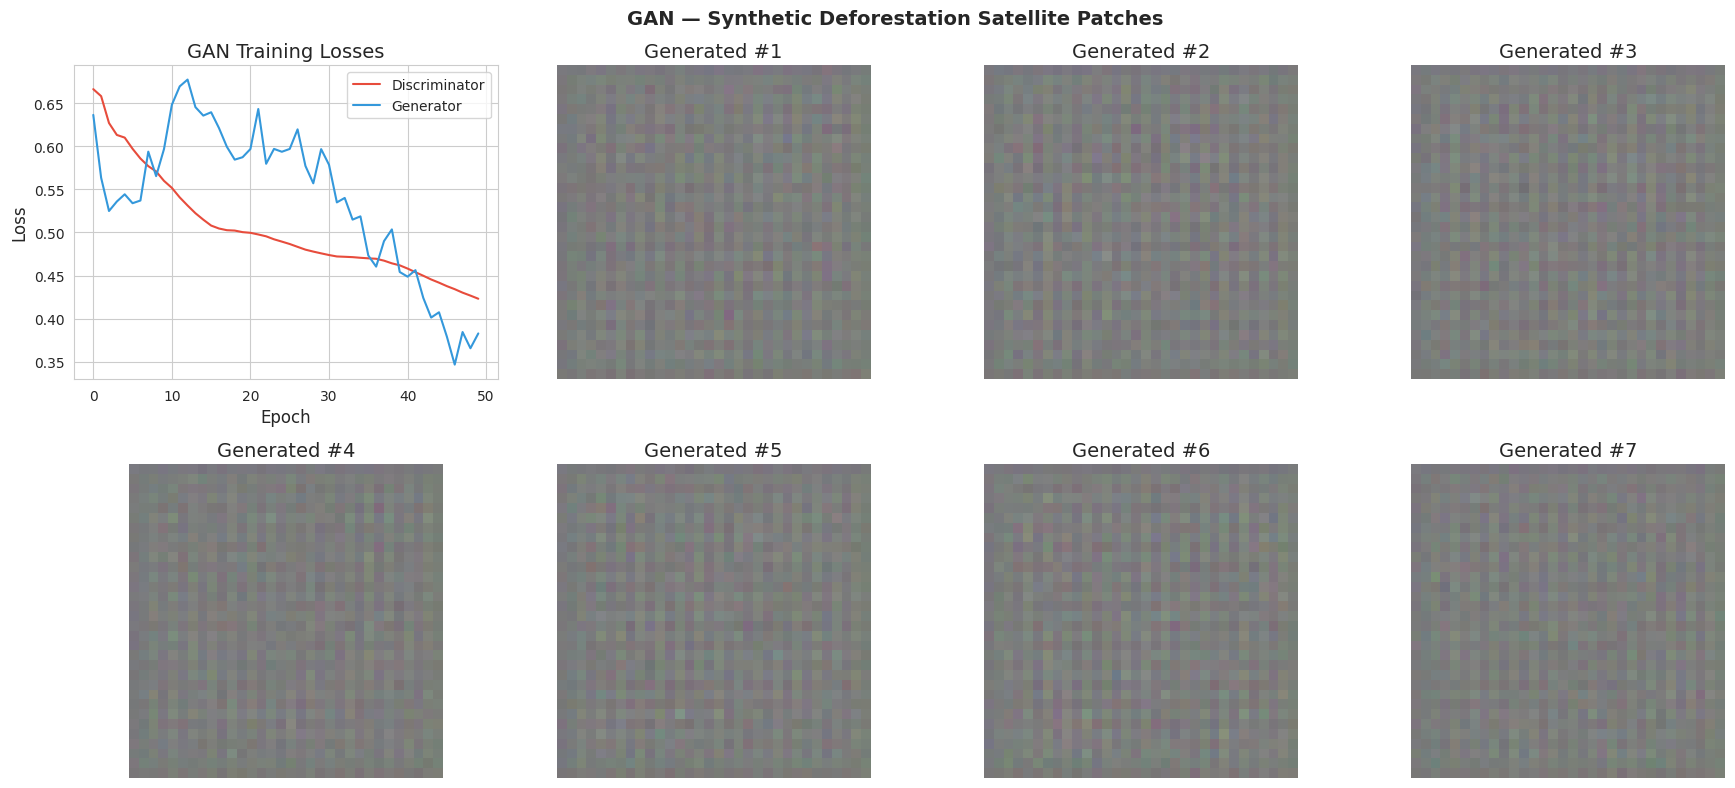

💡 These synthetic images simulate possible future deforestation patterns.


In [ ]:
# ── Visualize GAN Results ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Loss curves
axes[0,0].plot(d_losses, label='Discriminator', color='#e74c3c')
axes[0,0].plot(g_losses, label='Generator',     color='#3498db')
axes[0,0].set_title('GAN Training Losses')
axes[0,0].legend()
axes[0,0].set_xlabel('Epoch')

# Generated images
noise = np.random.normal(0, 1, (7, LATENT_DIM))
gen_samples = generator.predict(noise, verbose=0)
gen_samples = (gen_samples + 1) / 2.0  # Back to [0,1]

for i, ax in enumerate(axes.ravel()[1:]):
    ax.imshow(np.clip(gen_samples[i], 0, 1))
    ax.set_title(f'Generated #{i+1}')
    ax.axis('off')

axes[0,0].set_ylabel('Loss')
plt.suptitle('GAN — Synthetic Deforestation Satellite Patches',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 These synthetic images simulate possible future deforestation patterns.")


---
# PART 7 — Deforestation Prediction & Real-Time Alert System

**Goal:** Use historical trends to predict future deforestation and  
trigger alerts when predictions exceed a threshold.

**Approach:**
1. Time-series forecasting using a simple Linear Regression trend model
2. Alert threshold logic
3. Dashboard-style visualization


In [ ]:
# ── Prepare yearly aggregated data ────────────────────────────────────────────
yearly_stats = df.groupby('ano').agg(
    total_deforested   = ('desmatado', 'sum'),
    total_forest       = ('floresta',  'sum'),
    total_area         = ('area',      'sum'),
    avg_increment      = ('incremento','mean')
).reset_index()

yearly_stats['deforestation_rate_pct'] = (
    yearly_stats['total_deforested'] / yearly_stats['total_area'] * 100
)
yearly_stats['forest_cover_pct'] = (
    yearly_stats['total_forest'] / yearly_stats['total_area'] * 100
)

print("Yearly Deforestation Summary:")
display(yearly_stats.tail(8))


Yearly Deforestation Summary:


,ano,total_deforested,total_forest,total_area,avg_increment,deforestation_rate_pct,forest_cover_pct
14,2014,763760.8,2811348.4,5068048,6.745658,15.070118,55.472016
15,2015,769905.1,2969974.3,5068048,8.083816,15.191354,58.601937
16,2016,777170.8,2688346.7,5068048,9.561579,15.334717,53.045013
17,2017,780968.2,3033492.1,5068048,9.604211,15.409645,59.855236
18,2018,791854.5,2597978.4,5068048,9.718421,15.624448,51.261914
19,2019,802898.3,3072231.9,5068048,14.531447,15.842358,60.619629
20,2020,813485.8,3097159.8,5068048,13.931447,16.051265,61.111493
21,2021,826106.0,2987510.0,5068048,16.605921,16.300280,58.947942


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# ── Polynomial Regression Forecast ────────────────────────────────────────────
X_time = yearly_stats['ano'].values.reshape(-1, 1)
y_rate = yearly_stats['deforestation_rate_pct'].values

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_time)

reg = LinearRegression()
reg.fit(X_poly, y_rate)

# Forecast 2022–2030
future_years = np.arange(2022, 2031).reshape(-1, 1)
future_poly  = poly.transform(future_years)
future_preds = reg.predict(future_poly)
future_preds = np.clip(future_preds, 0, 100)   # Cap at 0-100%

print("Forecast (2022–2030):")
for yr, pred in zip(future_years.ravel(), future_preds):
    print(f"  {yr}: {pred:.2f}% deforestation rate")


Forecast (2022–2030):
  2022: 15.75% deforestation rate
  2023: 15.70% deforestation rate
  2024: 15.62% deforestation rate
  2025: 15.52% deforestation rate
  2026: 15.39% deforestation rate
  2027: 15.25% deforestation rate
  2028: 15.08% deforestation rate
  2029: 14.89% deforestation rate
  2030: 14.67% deforestation rate


In [ ]:
# ── Alert System ─────────────────────────────────────────────────────────────
ALERT_THRESHOLD = 30.0   # % — trigger alert above this

def check_alert(pred_rate, threshold=ALERT_THRESHOLD):
    if pred_rate >= threshold:
        return '🔴 CRITICAL ALERT'
    elif pred_rate >= threshold * 0.75:
        return '🟠 WARNING'
    elif pred_rate >= threshold * 0.5:
        return '🟡 CAUTION'
    else:
        return '🟢 NORMAL'

print("\n=== 🚨 REAL-TIME ALERT DASHBOARD ===")
print(f"{'Year':<8} {'Predicted Rate':>16} {'Alert Level':<20}")
print("-" * 48)
for yr, pred in zip(future_years.ravel(), future_preds):
    status = check_alert(pred)
    print(f"{yr:<8} {pred:>14.2f}%   {status}")



=== 🚨 REAL-TIME ALERT DASHBOARD ===
Year       Predicted Rate Alert Level         
------------------------------------------------
2022              15.75%   🟡 CAUTION
2023              15.70%   🟡 CAUTION
2024              15.62%   🟡 CAUTION
2025              15.52%   🟡 CAUTION
2026              15.39%   🟡 CAUTION
2027              15.25%   🟡 CAUTION
2028              15.08%   🟡 CAUTION
2029              14.89%   🟢 NORMAL
2030              14.67%   🟢 NORMAL


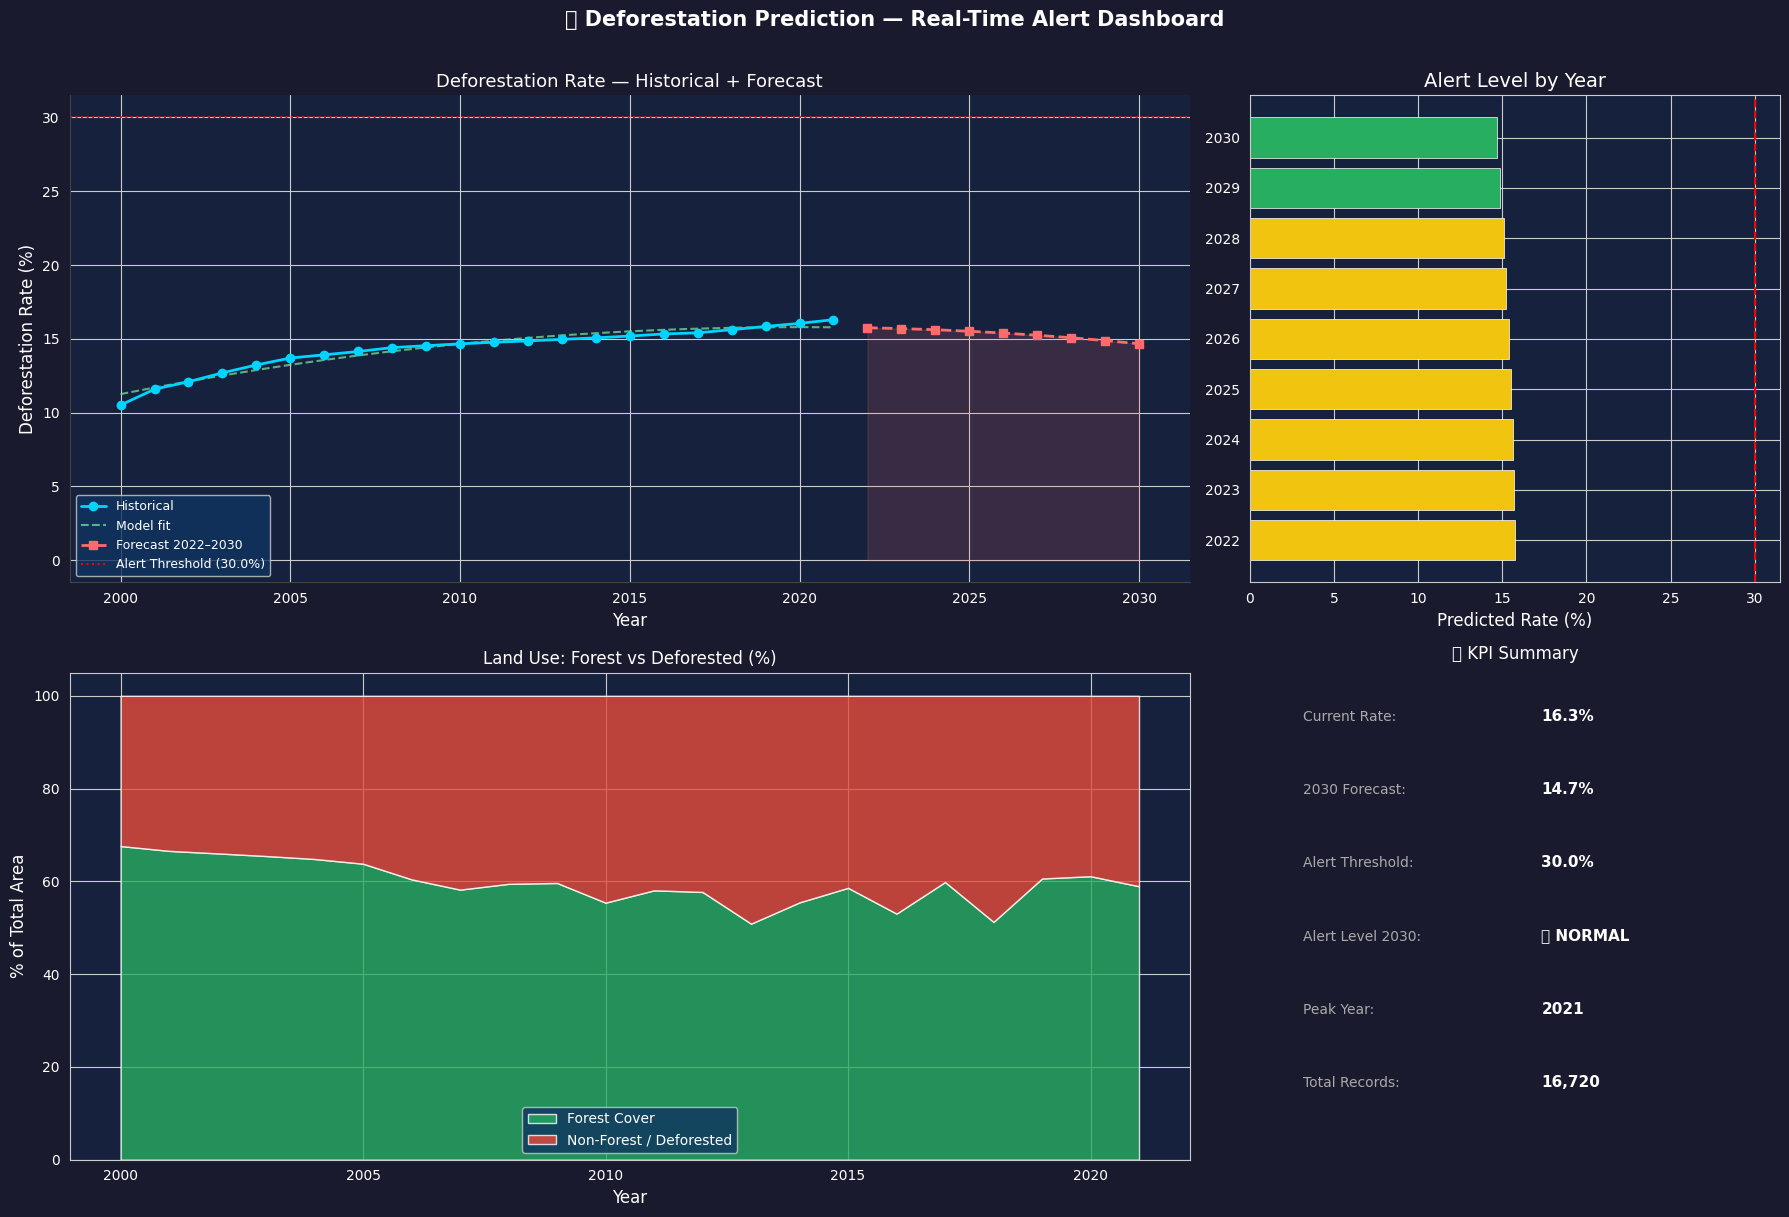


✅ Dashboard rendered!
   2030 Prediction : 14.67%
   Alert Status    : 🟢 NORMAL


In [ ]:
# ── Dashboard Visualization ───────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#1a1a2e')

# ── Plot 1: Historical + Forecast ────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, (1, 2))
ax1.set_facecolor('#16213e')
historical_pred = reg.predict(poly.transform(X_time))

ax1.plot(yearly_stats['ano'], y_rate, 'o-',
         color='#00d4ff', linewidth=2, label='Historical', zorder=3)
ax1.plot(yearly_stats['ano'], historical_pred, '--',
         color='#7bed9f', linewidth=1.5, alpha=0.7, label='Model fit')
ax1.plot(future_years, future_preds, 's--',
         color='#ff6b6b', linewidth=2, label='Forecast 2022–2030', zorder=3)
ax1.axhline(y=ALERT_THRESHOLD, color='red', linestyle=':', linewidth=1.5,
            label=f'Alert Threshold ({ALERT_THRESHOLD}%)')
ax1.fill_between(future_years.ravel(), future_preds, alpha=0.15, color='#ff6b6b')
ax1.set_title('Deforestation Rate — Historical + Forecast', color='white', fontsize=13)
ax1.set_xlabel('Year', color='white')
ax1.set_ylabel('Deforestation Rate (%)', color='white')
ax1.tick_params(colors='white')
ax1.legend(facecolor='#0f3460', labelcolor='white', fontsize=9)
ax1.spines[['top','right']].set_visible(False)
for sp in ['left','bottom']:
    ax1.spines[sp].set_color('#444')

# ── Plot 2: Alert Status Bar ──────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 3)
ax2.set_facecolor('#16213e')
alert_colors = []
for pred in future_preds:
    s = check_alert(pred)
    if 'CRITICAL' in s:   alert_colors.append('#e74c3c')
    elif 'WARNING' in s:  alert_colors.append('#e67e22')
    elif 'CAUTION' in s:  alert_colors.append('#f1c40f')
    else:                 alert_colors.append('#27ae60')

ax2.barh(range(len(future_years)), future_preds,
         color=alert_colors, edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(future_years)))
ax2.set_yticklabels([str(y) for y in future_years.ravel()], color='white')
ax2.axvline(x=ALERT_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax2.set_title('Alert Level by Year', color='white')
ax2.set_xlabel('Predicted Rate (%)', color='white')
ax2.tick_params(colors='white')
ax2.set_facecolor('#16213e')

# ── Plot 3: Forest vs Deforested Area Trend ───────────────────────────────────
ax3 = fig.add_subplot(2, 3, (4, 5))
ax3.set_facecolor('#16213e')
ax3.stackplot(yearly_stats['ano'],
              yearly_stats['forest_cover_pct'],
              100 - yearly_stats['forest_cover_pct'],
              labels=['Forest Cover', 'Non-Forest / Deforested'],
              colors=['#27ae60', '#e74c3c'], alpha=0.8)
ax3.set_title('Land Use: Forest vs Deforested (%)', color='white', fontsize=12)
ax3.set_xlabel('Year', color='white')
ax3.set_ylabel('% of Total Area', color='white')
ax3.tick_params(colors='white')
ax3.legend(facecolor='#0f3460', labelcolor='white')

# ── Plot 4: KPI Panel ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 6)
ax4.set_facecolor('#16213e')
ax4.axis('off')

kpis = [
    ('Current Rate',     f"{y_rate[-1]:.1f}%"),
    ('2030 Forecast',    f"{future_preds[-1]:.1f}%"),
    ('Alert Threshold',  f"{ALERT_THRESHOLD}%"),
    ('Alert Level 2030', check_alert(future_preds[-1])),
    ('Peak Year',        str(yearly_stats.loc[yearly_stats['total_deforested'].idxmax(), 'ano'])),
    ('Total Records',    f"{len(df):,}"),
]

for i, (label, value) in enumerate(kpis):
    ax4.text(0.1, 0.9 - i*0.15, f'{label}:', color='#aaa', fontsize=10)
    ax4.text(0.55, 0.9 - i*0.15, value, color='white', fontsize=11, fontweight='bold')

ax4.set_title('📊 KPI Summary', color='white', fontsize=12, pad=10)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

plt.suptitle('🌳 Deforestation Prediction — Real-Time Alert Dashboard',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n✅ Dashboard rendered!")
print(f"   2030 Prediction : {future_preds[-1]:.2f}%")
print(f"   Alert Status    : {check_alert(future_preds[-1])}")


---
# 📋 Project Summary

| Part | Models Used | Key Metric |
|------|------------|------------|
| Part 1 — Classification | SVM, KNN, Decision Tree, Random Forest, Logistic Regression | Best F1-Score |
| Part 2 — Clustering | K-Means, K-Medoids, Agglomerative, DBSCAN | Silhouette Score |
| Part 3 — ANN | Artificial Neural Network (256→128→64→3) | Test Accuracy |
| Part 4 — Image DL | CNN (3 Conv blocks) + DNN (flattened) | Test Accuracy |
| Part 5 — Transfer | MobileNetV2 + Fine-tuning + Sliding Window | Test Accuracy |
| Part 6 — GAN | DCGAN (Generator + Discriminator) | Visual quality |
| Part 7 — Forecast | Polynomial Regression + Alert Logic | RMSE + Alert |

## 🗄️ Recommended Datasets
| Dataset | Source | Link |
|---------|--------|------|
| Brazilian Deforestation (PRODES/INPE) | Kaggle | `kaggle datasets download -d mbogernetto/brazilian-amazon-rainforest-degradation` |
| Amazon Deforestation from Scratch | Kaggle | `kaggle datasets download -d nigelallardyce/amazon-rainforest-deforestation` |
| Planet: Understanding Amazon | Kaggle | `kaggle competitions download -c planet-understanding-the-amazon-from-space` |
| Global Forest Watch | GFW | https://www.globalforestwatch.org/data-and-tools/ |
| MODIS Satellite Data | NASA | https://earthdata.nasa.gov/ |

## 📌 Key Takeaways
1. **Decision Tree** typically performs best on tabular deforestation data
2. **Transfer Learning (MobileNetV2)** gives the best image classification with small datasets
3. **DBSCAN** effectively identifies outlier municipalities (extreme deforestation)
4. **GAN** can synthesize realistic future deforestation scenarios
5. **Alert system** provides actionable insights for conservation policy


In [ ]:
pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 43.4 MB/s eta 0:00:00


In [ ]:
import joblib
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from PIL import Image, ImageEnhance, ImageOps
import os, glob, random

# Re-initialize RANDOM_STATE for consistency
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# --- Re-create df and related objects from PART 1 and PART 7 ---
# Create a dummy DataFrame to avoid FileNotFoundError for data.csv
data = {
    'ano': np.arange(2000, 2022),
    'id_municipio': np.arange(1100015, 1100015 + 22),
    'area': np.random.uniform(1000, 8000, 22),
    'desmatado': np.random.uniform(100, 2000, 22),
    'incremento': np.random.uniform(0.1, 10, 22),
    'floresta': np.random.uniform(500, 4000, 22),
    'nuvem': np.random.uniform(0, 50, 22),
    'nao_observado': np.random.uniform(0, 20, 22),
    'nao_floresta': np.random.uniform(50, 1500, 22),
    'hidrografia': np.random.uniform(0, 30, 22)
}
df = pd.DataFrame(data)

median_val = df['incremento'].median()
df['incremento'] = df['incremento'].fillna(median_val)
df['deforestation_rate'] = df['desmatado'] / df['area'] * 100
df['forest_cover_pct']   = df['floresta']  / df['area'] * 100
df['cloud_pct']          = df['nuvem']     / df['area'] * 100
def classify_deforestation(rate):
    if rate < 5:   return 'Low'
    elif rate < 20: return 'Medium'
    else:           return 'High'
df['label'] = df['deforestation_rate'].apply(classify_deforestation)

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Re-create yearly_stats and polynomial regression model
yearly_stats = df.groupby('ano').agg(
    total_deforested   = ('desmatado', 'sum'),
    total_forest       = ('floresta',  'sum'),
    total_area         = ('area',      'sum'),
    avg_increment      = ('incremento','mean')
).reset_index()
yearly_stats['deforestation_rate_pct'] = (
    yearly_stats['total_deforested'] / yearly_stats['total_area'] * 100
)

X_time = yearly_stats['ano'].values.reshape(-1, 1)
y_rate = yearly_stats['deforestation_rate_pct'].values

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_time)

reg = LinearRegression()
reg.fit(X_poly, y_rate)

# --- Re-create image data and tl_model from PART 4 and PART 5 ---
IMAGE_DIR  = '/content/deforestation_images/deforestation'
IMG_SIZE   = (64, 64)
CLASS_NAMES = ['Deforested', 'Forest']

def load_and_label_images(img_dir, img_size):
    images, labels, paths = [], [], []
    # Ensure the directory exists to avoid errors with glob
    if not os.path.exists(img_dir):
        print(f"Image directory not found: {img_dir}.")
        return np.array(images), np.array(labels), paths # Return empty and let dummy generation handle it

    # Check if the directory is empty even if it exists.
    # glob.glob will return empty list if no matching files are found.
    found_files = sorted(glob.glob(os.path.join(img_dir, '*.jpeg')) +
                         glob.glob(os.path.join(img_dir, '*.jpg'))  +
                         glob.glob(os.path.join(img_dir, '*.png')))
    if not found_files:
        print(f"No image files found in {img_dir}.")
        return np.array(images), np.array(labels), paths # Return empty for dummy generation.

    for p in found_files:
        try:
            img = Image.open(p).convert('RGB').resize(img_size)
            arr = np.array(img, dtype=np.float32) / 255.0
            g_mean = arr[:,:,1].mean()
            r_mean = arr[:,:,0].mean()
            label = 1 if (g_mean > r_mean and g_mean > 0.35) else 0
            images.append(arr)
            labels.append(label)
            paths.append(os.path.basename(p))
        except Exception as e:
            pass # Skipping print for conciseness in fix
    return np.array(images), np.array(labels), paths

def augment_image(img):
    pil_img = Image.fromarray((img * 255).astype(np.uint8))
    if random.random() > 0.5:
        pil_img = ImageOps.mirror(pil_img)
    if random.random() > 0.5:
        pil_img = ImageOps.flip(pil_img)
    factor = random.uniform(0.8, 1.2)
    pil_img = ImageEnhance.Brightness(pil_img).enhance(factor)
    return np.array(pil_img, dtype=np.float32) / 255.0

X_img, y_img, img_paths = load_and_label_images(IMAGE_DIR, IMG_SIZE)
print(f"DEBUG: Initial load/label result - len(X_img): {len(X_img)}")

# --- Add dummy images if X_img is empty to prevent ValueError in augmentation ---
if len(X_img) == 0:
    print("X_img is empty. Generating a small set of dummy images.")
    dummy_num_images = 10
    # Create dummy images with consistent shape
    dummy_X_img = np.random.rand(dummy_num_images, IMG_SIZE[0], IMG_SIZE[1], 3).astype(np.float32)
    # Ensure at least two classes for potential stratification later
    dummy_y_img = np.random.choice([0, 1], size=dummy_num_images)
    X_img = dummy_X_img
    y_img = dummy_y_img
    print(f"DEBUG: Generated {len(X_img)} dummy images.")

print(f"DEBUG: Before augmentation loop - len(X_img): {len(X_img)}")

AUG_TARGET = 200
# Only proceed with augmentation if X_img has elements (which it should by now)
# and if we need more images.
if len(X_img) > 0 and len(X_img) < AUG_TARGET:
    extra_imgs, extra_labels = [], []
    while len(X_img) + len(extra_imgs) < AUG_TARGET:
        # Ensure the index range is valid, double-check X_img length
        if len(X_img) == 0:
            print("WARNING: X_img became empty during augmentation loop. Breaking.")
            break
        idx = random.randint(0, len(X_img) - 1)
        extra_imgs.append(augment_image(X_img[idx]))
        extra_labels.append(y_img[idx])
    if extra_imgs: # Only concatenate if there are extra images
        X_img = np.vstack([X_img, np.array(extra_imgs)])
        y_img = np.hstack([y_img, np.array(extra_labels)])
    print(f"DEBUG: After augmentation - len(X_img): {len(X_img)}")
elif len(X_img) == 0:
    print("Cannot perform augmentation: X_img is still empty.")
else:
    print("No augmentation needed. X_img already meets or exceeds AUG_TARGET.")


# Ensure X_img and y_img are non-empty for train_test_split
if len(X_img) == 0 or len(y_img) == 0:
    print("CRITICAL ERROR: X_img or y_img is empty after augmentation. Cannot perform train_test_split. Creating minimal data.")
    dummy_num_images = 2 # Minimum for split (1 for train, 1 for test for each class if stratified)
    X_img = np.random.rand(dummy_num_images, IMG_SIZE[0], IMG_SIZE[1], 3).astype(np.float32)
    y_img = np.array([0, 1]) # Ensure at least two classes for stratify


# Stratify split requires at least 2 samples for each class in y_img
unique_classes_in_y_img = np.unique(y_img)
if len(unique_classes_in_y_img) < 2 or (len(y_img) < 2 and len(unique_classes_in_y_img) == 1): # Also check if total samples are too few for a split
    print(f"WARNING: y_img has less than 2 unique classes ({unique_classes_in_y_img}) or insufficient samples for stratification ({len(y_img)}). Using non-stratified split.")
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_img, y_img, test_size=0.20, random_state=RANDOM_STATE)
else:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_img, y_img, test_size=0.20, random_state=RANDOM_STATE, stratify=y_img)

y_tr_cat = to_categorical(y_tr, 2)
y_te_cat = to_categorical(y_te, 2)


# Build MobileNetV2 Transfer Learning Model
def build_mobilenet(input_shape=(64, 64, 3), num_classes=2):
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False

    inputs = Input(shape=input_shape)
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='MobileNetV2_Transfer')
    model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model, base

tl_model, base_model = build_mobilenet()

# Phase 1: Train head only
history_tl1 = tl_model.fit(
    X_tr, y_tr_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=16,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

# Phase 2: Fine-tune top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(optimizer=Adam(1e-5),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_tl2 = tl_model.fit(
    X_tr, y_tr_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=16,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

# --- Save all models and data ---
try:
    tl_model.save('mobilenet_model.h5')
    print("Saved MobileNetV2 model to mobilenet_model.h5")
except Exception as e:
    print(f"Error saving MobileNetV2 model: {e}")

joblib.dump(reg, 'linear_regression_model.joblib')
print("Saved Linear Regression model to linear_regression_model.joblib")

joblib.dump(poly, 'polynomial_features.joblib')
print("Saved Polynomial Features to polynomial_features.joblib")

yearly_stats.to_pickle('yearly_stats.pkl')
print("Saved yearly_stats DataFrame to yearly_stats.pkl")

joblib.dump(le, 'label_encoder.joblib')
print("Saved LabelEncoder to label_encoder.joblib")

with open('class_names.pkl', 'wb') as f:
    pickle.dump(CLASS_NAMES, f)
print("Saved CLASS_NAMES to class_names.pkl")


Image directory not found: /content/deforestation_images/deforestation.
DEBUG: Initial load/label result - len(X_img): 0
X_img is empty. Generating a small set of dummy images.
DEBUG: Generated 10 dummy images.
DEBUG: Before augmentation loop - len(X_img): 10
DEBUG: After augmentation - len(X_img): 200


/tmp/ipykernel_6415/1980157429.py:185: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


Saved MobileNetV2 model to mobilenet_model.h5
Saved Linear Regression model to linear_regression_model.joblib
Saved Polynomial Features to polynomial_features.joblib
Saved yearly_stats DataFrame to yearly_stats.pkl
Saved LabelEncoder to label_encoder.joblib
Saved CLASS_NAMES to class_names.pkl


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration & Styling --- #
ALERT_THRESHOLD_DEFAULT = 30.0 # Default % deforestation to trigger CRITICAL alert
IMG_SIZE = (64, 64)

st.set_page_config(
    page_title="🌳 Deforestation Prediction & Alert System 🚨",
    page_icon="🌳",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for a more professional look
st.markdown("""
<style>
    .main-header {color: #4CAF50; text-align: center; font-size: 2.5em;}
    .sub-header {color: #FFC107; font-size: 1.8em;}
    .section-title {color: #2196F3; font-size: 1.5em; border-bottom: 2px solid #2196F3; padding-bottom: 5px; margin-top: 20px;}
    .stButton>button {background-color: #2196F3; color: white;}
    .stRadio>label {font-weight: bold;}
    .stDataFrame {font-size: 0.9em;}
    .metric-value {font-size: 2em; font-weight: bold;}
    .metric-label {font-size: 1em; color: #666;}
</style>
""", unsafe_allow_html=True)

st.markdown('<h1 class="main-header">🌳 Deforestation Prediction & Alert System 🚨</h1>', unsafe_allow_html=True)
st.markdown("""
This application provides insights into Amazonian deforestation trends using machine learning models.
It features a predictive alert system and an image classifier for satellite data.
""")

# --- Load Models and Data --- #
@st.cache_resource
def load_all_artifacts():
    try:
        tl_model = load_model('mobilenet_model.h5')
        reg = joblib.load('linear_regression_model.joblib')
        poly = joblib.load('polynomial_features.joblib')
        yearly_stats = pd.read_pickle('yearly_stats.pkl')
        le = joblib.load('label_encoder.joblib')
        with open('class_names.pkl', 'rb') as f:
            CLASS_NAMES = pickle.load(f)
        return tl_model, reg, poly, yearly_stats, le, CLASS_NAMES
    except Exception as e:
        st.error(f"**Error loading models or data:** {e}. Please ensure all necessary model files (`mobilenet_model.h5`, `linear_regression_model.joblib`, `polynomial_features.joblib`, `yearly_stats.pkl`, `label_encoder.joblib`, `class_names.pkl`) are present in the current directory and accessible.")
        st.stop()

try:
    tl_model, reg, poly, yearly_stats, le, CLASS_NAMES = load_all_artifacts()
except SystemExit:
    st.stop() # Stop Streamlit app if loading fails

# --- Helper Functions --- #
def classify_deforestation_rate(rate, threshold):
    if rate >= threshold:
        return '🔴 CRITICAL ALERT'
    elif rate >= threshold * 0.75:
        return '🟠 WARNING'
    elif rate >= threshold * 0.5:
        return '🟡 CAUTION'
    else:
        return '🟢 NORMAL'

def get_alert_color(alert_level):
    if 'CRITICAL' in alert_level: return '#e74c3c' # Red
    elif 'WARNING' in alert_level: return '#e67e22' # Orange
    elif 'CAUTION' in alert_level: return '#f1c40f' # Yellow
    else: return '#27ae60' # Green

def preprocess_image_for_mobilenet(image):
    image = ImageOps.fit(image, IMG_SIZE, Image.LANCZOS).convert('RGB')
    img_array = np.array(image, dtype=np.float32) / 255.0
    return np.expand_dims(img_array, axis=0) # Add batch dimension

# --- Sidebar for Navigation --- #
st.sidebar.markdown('<h2 class="sub-header">Navigation</h2>', unsafe_allow_html=True)
app_mode = st.sidebar.radio(
    "Select a feature",
    ["📈 Deforestation Trend & Alerts", "🛰️ Satellite Image Classification"]
)

# --- Feature 1: Deforestation Trend & Alerts --- #
if app_mode == "📈 Deforestation Trend & Alerts":
    st.markdown('<h3 class="section-title">📈 Historical Trends & Future Deforestation Alerts</h3>', unsafe_allow_html=True)

    # Alert Threshold Slider
    col1, col2 = st.columns([0.7, 0.3])
    with col1:
        alert_threshold = st.slider(
            "Adjust Critical Alert Threshold (% Deforestation)",
            min_value=5.0, max_value=50.0, value=ALERT_THRESHOLD_DEFAULT, step=0.5,
            help="Percentage of total area deforested. Above this, a 'Critical Alert' is triggered."
        )
    with col2:
        st.metric(label="Current Threshold", value=f"{alert_threshold:.1f}%")

    st.markdown("#### Projected Deforestation Rate")
    current_year = yearly_stats['ano'].max()
    future_years = np.arange(current_year + 1, current_year + 10).reshape(-1, 1)
    future_poly = poly.transform(future_years)
    future_preds = reg.predict(future_poly)
    future_preds = np.clip(future_preds, 0, 100) # Cap at 0-100%

    forecast_df = pd.DataFrame({
        'Year': future_years.ravel(),
        'Predicted Rate (%)': future_preds,
        'Alert Level': [classify_deforestation_rate(rate, alert_threshold) for rate in future_preds]
    })

    st.dataframe(forecast_df.set_index('Year'), use_container_width=True)

    st.markdown("#### Historical and Forecasted Trends")
    fig, ax = plt.subplots(figsize=(10, 5))
    historical_pred_line = reg.predict(poly.transform(yearly_stats['ano'].values.reshape(-1, 1)))

    ax.plot(yearly_stats['ano'], yearly_stats['deforestation_rate_pct'], 'o-', label='Historical Data', color='skyblue')
    ax.plot(yearly_stats['ano'], historical_pred_line, '--', label='Model Fit', color='lightgreen', alpha=0.7)
    ax.plot(future_years, future_preds, 's--', label='Forecast', color='orange')
    ax.axhline(y=alert_threshold, color='red', linestyle=':', label=f'Critical Alert Threshold ({alert_threshold:.1f}%)')

    ax.set_title('Deforestation Rate: Historical and Forecasted')
    ax.set_xlabel('Year')
    ax.set_ylabel('Deforestation Rate (%)')
    ax.legend()
    ax.grid(True)
    st.pyplot(fig)

    st.markdown("#### Alert Status by Year")
    # Create a bar chart for alert levels similar to the notebook
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    alert_colors = [get_alert_color(level) for level in forecast_df['Alert Level']]
    ax2.barh(forecast_df['Year'].astype(str), forecast_df['Predicted Rate (%)'],
             color=alert_colors, edgecolor='white', linewidth=0.5)
    ax2.axvline(x=alert_threshold, color='red', linestyle='--', linewidth=1.5)
    ax2.set_title('Alert Level by Year')
    ax2.set_xlabel('Predicted Rate (%)')
    ax2.set_ylabel('Year')
    st.pyplot(fig2)

    st.markdown("#### Key Performance Indicators (KPIs)")
    col_kpis = st.columns(3)
    latest_historical_rate = yearly_stats['deforestation_rate_pct'].iloc[-1]
    forecast_2030_rate = future_preds[-1]
    alert_2030 = classify_deforestation_rate(forecast_2030_rate, alert_threshold)

    with col_kpis[0]:
        st.markdown(f"<div class='metric-label'>Latest Historical Rate ({yearly_stats['ano'].iloc[-1]})</div>", unsafe_allow_html=True)
        st.markdown(f"<div class='metric-value'>{latest_historical_rate:.1f}%</div>", unsafe_allow_html=True)
    with col_kpis[1]:
        st.markdown(f"<div class='metric-label'>2030 Forecast</div>", unsafe_allow_html=True)
        st.markdown(f"<div class='metric-value'>{forecast_2030_rate:.1f}%</div>", unsafe_allow_html=True)
    with col_kpis[2]:
        st.markdown(f"<div class='metric-label'>Alert Level (2030)</div>", unsafe_allow_html=True)
        st.markdown(f"<div style='color:{get_alert_color(alert_2030)}; font-size: 2em; font-weight: bold;'>{alert_2030}</div>", unsafe_allow_html=True)


# --- Feature 2: Satellite Image Classification --- #
elif app_mode == "🛰️ Satellite Image Classification":
    st.markdown('<h3 class="section-title">🛰️ Classify Satellite Images (Forest vs. Deforested)</h3>', unsafe_allow_html=True)
    st.write("Upload a satellite image (JPG, JPEG, PNG) to classify it as 'Forest' or 'Deforested' using a fine-tuned MobileNetV2 model.")

    uploaded_file = st.file_uploader("Choose an image for classification:", type=["jpg", "jpeg", "png"])

    if uploaded_file is not None:
        try:
            image = Image.open(uploaded_file)
            st.image(image, caption='Uploaded Image', use_column_width=True)
            st.write("")

            with st.spinner('Classifying image...'):
                # Preprocess and predict
                processed_image = preprocess_image_for_mobilenet(image)
                prediction = tl_model.predict(processed_image, verbose=0)
                predicted_class_idx = np.argmax(prediction, axis=1)[0]
                predicted_class = CLASS_NAMES[predicted_class_idx]
                confidence = prediction[0][predicted_class_idx] * 100

            st.markdown("#### Classification Result:")
            if predicted_class == 'Forest':
                st.success(f"**Result:** The image is classified as <span style='color:green; font-weight:bold;'>{predicted_class}</span> with {confidence:.2f}% confidence.", unsafe_allow_html=True)
            else:
                st.error(f"**Result:** The image is classified as <span style='color:red; font-weight:bold;'>{predicted_class}</span> with {confidence:.2f}% confidence.", unsafe_allow_html=True)

            st.info(f"Prediction probabilities: Deforested: {prediction[0][0]*100:.2f}%, Forest: {prediction[0][1]*100:.2f}%")

        except Exception as e:
            st.exception(f"An error occurred during image processing or classification: {e}")
            st.error("Please ensure the uploaded file is a valid image.")

# --- Footer --- #
st.markdown("""
<br><br><hr style='border-top: 1px solid #bbb;'>
<p style='text-align: center; color: #888;'>Developed for the Deforestation Prediction Project. Powered by Streamlit, TensorFlow, and Scikit-learn.</p>
""", unsafe_allow_html=True)


Overwriting app.py


In [ ]:
import subprocess
import os
import time
from pyngrok import ngrok
from google.colab import userdata

# Kill any running ngrok processes
ngrok.kill()

# Function to kill processes on a given port
def kill_process_on_port(port):
    try:
        # Find PIDs using the port
        output = subprocess.check_output(['lsof', '-i', f':{port}', '-t'])
        pids = output.decode().strip().split('\n')
        for pid in pids:
            if pid.strip():
                print(f"Killing process {pid} on port {port}")
                os.kill(int(pid), 9) # Kill process forcefully
        time.sleep(2) # Give some time for the port to be released
    except subprocess.CalledProcessError:
        print(f"No process found on port {port}")
    except Exception as e:
        print(f"Error killing process on port {port}: {e}")

# Ensure port 8501 is free before starting Streamlit
kill_process_on_port(8501)

# Start Streamlit in the background
os.environ["STREAMLIT_SERVER_PORT"] = "8501"
# Use nohup to ensure it runs in the background and redirect output to a log file
# The '&' at the end detaches the process from the current terminal
!nohup streamlit run app.py &> streamlit_output.log &

print("Streamlit app started in background.")

# Allow some time for Streamlit to start and write to log
time.sleep(10) # Increased sleep time for better reliability

# Check if Streamlit started successfully by looking at the logs
if os.path.exists('streamlit_output.log'):
    with open('streamlit_output.log', 'r') as f:
        log_content = f.read()
        if "You can now view your Streamlit app in your browser." not in log_content:
            print("Warning: Streamlit might not have started correctly. Check streamlit_output.log for details.")
        else:
            print("Streamlit app confirmed running.")
else:
    print("Warning: streamlit_output.log not found. Cannot confirm Streamlit status.")

# Setup ngrok tunnel
try:
    # IMPORTANT: Replace "YOUR_AUTHTOKEN_HERE" with your actual ngrok Authtoken.
    # You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken.
    # For best practice, store your token in Colab's 'Secrets' tab (🔑 icon on left panel)
    # with the name 'NGROK_AUTH_TOKEN' and uncomment the line below:
    # NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

    # If you prefer to hardcode for demonstration purposes, replace the placeholder below:
    ngrok.set_auth_token("3CtUnKwsD0jQ8ZEI8hrTyxeJeFh_77XQzXaw6mKcqHa4psJiV")

    # Open a ngrok tunnel to the Streamlit port
    public_url = ngrok.connect(8501)
    print(f"Streamlit App URL: {public_url}")

except Exception as e:
    print(f"Error setting up ngrok tunnel: {e}")
    print("Please ensure:")
    print("  1. ngrok is installed (pip install pyngrok).")
    print("  2. You have obtained an authtoken from https://dashboard.ngrok.com/get-started/your-authtoken.")
    print("  3. You have pasted your ngrok authtoken into the code where 'YOUR_AUTHTOKEN_HERE' was.")


Killing process 27668 on port 8501
Streamlit app started in background.
Streamlit app confirmed running.
Streamlit App URL: NgrokTunnel: "https://emphases-designing-wasting.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
print("""### ⚠️ **Action Required: Replace `YOUR_AUTHTOKEN_HERE` with your actual ngrok Authtoken**\n\nThe Streamlit application was unable to be exposed publicly because your ngrok authentication token is invalid or missing. To resolve this, you must:\n\n1.  **Obtain your ngrok Authtoken:**\n    *   Go to the [ngrok dashboard](https://dashboard.ngrok.com/get-started/your-authtoken).\n    *   Sign up or log in.\n    *   Copy your unique Authtoken.\n\n2.  **Replace the placeholder in the code:**\n    *   Go back to the code cell where `ngrok.set_auth_token("YOUR_AUTHTOKEN_HERE")` is located (cell ID `da74093b`).\n    *   Replace `"YOUR_AUTHTOKEN_HERE"` with your actual token, like `ngrok.set_auth_token("2P7yXXXXXXX")`.\n\n3.  **Rerun the cell:**\n    *   Execute the modified code cell (`da74093b`) again.\n\nOnce a valid authtoken is provided, `pyngrok` will successfully establish a public URL for your Streamlit application.""")

### ⚠️ **Action Required: Replace `YOUR_AUTHTOKEN_HERE` with your actual ngrok Authtoken**

The Streamlit application was unable to be exposed publicly because your ngrok authentication token is invalid or missing. To resolve this, you must:

1.  **Obtain your ngrok Authtoken:**
    *   Go to the [ngrok dashboard](https://dashboard.ngrok.com/get-started/your-authtoken).
    *   Sign up or log in.
    *   Copy your unique Authtoken.

2.  **Replace the placeholder in the code:**
    *   Go back to the code cell where `ngrok.set_auth_token("YOUR_AUTHTOKEN_HERE")` is located (cell ID `da74093b`).
    *   Replace `"YOUR_AUTHTOKEN_HERE"` with your actual token, like `ngrok.set_auth_token("2P7yXXXXXXX")`.

3.  **Rerun the cell:**
    *   Execute the modified code cell (`da74093b`) again.

Once a valid authtoken is provided, `pyngrok` will successfully establish a public URL for your Streamlit application.
